# UFC Fight Outcome Prediction

Predicting UFC fight winners with an Optuna-tuned XGBoost + LightGBM
ensemble, evaluated with rolling-window cross validation.

## Table of Contents
- [Imports and Settings](#imports-and-settings)
- [Helper Functions](#helper-functions)
- [Load and Inspect Raw Data](#load-and-inspect-raw-data)
- [Clean Fighter Data](#clean-fighter-data)
- [Clean Fight Data](#clean-fight-data)
- [Merge Fighters and Fights](#merge-fighters-and-fights)
- [Feature: Prior Career Average Stats](#feature-prior-career-average-stats)
- [Feature: Prior Career Median Stats](#feature-prior-career-median-stats)
- [Feature: Won Last Fight](#feature-won-last-fight)
- [Feature: Won Last Three Fights](#feature-won-last-three-fights)
- [Feature: Win Streak](#feature-win-streak)
- [Feature: Losing Streak](#feature-losing-streak)
- [Feature: Fight Frequency and Layoff](#feature-fight-frequency-and-layoff)
- [Feature: Matchup Differentials](#feature-matchup-differentials)
- [Feature: Head-to-Head and Finish Rates](#feature-head-to-head-and-finish-rates)
- [Feature: Elo Rating](#feature-elo-rating)
- [Target and Feature Selection](#target-and-feature-selection)
- [Correlation Heatmap](#correlation-heatmap)
- [Rolling Window Size Search](#rolling-window-size-search)
- [Select Best Window and Build Training Set](#select-best-window-and-build-training-set)
- [Hyperparameter Tuning with Optuna](#hyperparameter-tuning-with-optuna)
- [Hyperparameter Tuning with Optuna (LightGBM)](#hyperparameter-tuning-with-optuna-lightgbm)
- [Final Holdout Test Split](#final-holdout-test-split)
- [Ensemble of Top Trials](#ensemble-of-top-trials)
- [Top Trial Parameters](#top-trial-parameters)
- [Ensemble Metrics](#ensemble-metrics)
- [Probability Calibration](#probability-calibration)
- [Threshold Selection](#threshold-selection)
- [Test Set Stability Check](#test-set-stability-check)
- [Paired Comparison vs. Baseline (McNemar)](#paired-comparison-vs-baseline-mcnemar)
- [Single Fight Prediction](#single-fight-prediction)
- [Export for Streamlit App](#export-for-streamlit-app)

## Roadmap
- [x] Check code for win/loss streak
- [x] Check code for fight frequency
- [x] Check code for previous 1/3 win streak
- [x] Continue with hyperparameter tuning
- [x] Fix prediction cell
- [x] Add a dashboard (see `app.py`)
- [ ] Add gbm.set_params(class_weight = {0: 1.5, 1: 1.0})   # penalise FP more
- [x] Tune the ensemble of models more (LightGBM now Optuna-tuned; blend
      weight moved off 0.0 for the first time -- see Ensemble of Top Trials)
- [ ] Try a neural network
- [ ] Add betting-odds as a feature and as a benchmark to beat
- [x] Compute the med_*/avg_* correlation dedup (Target and Feature Selection)
      against the real train_end instead of the approximate date-quantile
      cutoff -- tested: the 85th-percentile proxy and the exact train_end
      produce identical dedup decisions, so this was a non-issue. No code
      change made.
- [x] Tighten the avg_*/med_* correlation-dedup threshold (now 0.85, was
      0.95) -- validated in isolation first (+0.003 AUC on one window's CV),
      then confirmed via full run. Note: this feature-set change also shifted
      the rolling-window search's pick (48/12 -> 60/6 months), shrinking the
      final test set from 230 to 110 fights -- a real, if unintended,
      side effect worth knowing about.
- [ ] Recency-weight the prior-fight averages (exponential decay instead of a
      flat expanding mean)
- [x] Stability-check the rolling-window selection stage across multiple
      random seeds -- tested: zero AUC variance across seeds for the top 5
      candidate windows (create_xgb_model() has no subsampling enabled, so
      random_state has nothing to seed). The window pick is fully
      deterministic, not seed-dependent.
- [x] Get real win frequencies out of the model -- fit Platt scaling on
      pooled walk-forward CV out-of-fold predictions (thousands of fights,
      not the 120-fight validation slice) for display purposes; a dedicated
      experiment confirmed retuning the *decision threshold* on calibrated
      scores doesn't beat the raw score at 0.5, so the decision rule is
      untouched -- see Probability Calibration.
- [x] Fix "Light Heavyweight" fights being silently bucketed as
      "Heavyweight" -- pull_words() matched the "Heavyweight" substring
      before checking for the real thing, which isn't a coincidental few
      rows: 763 of 1540 "Heavyweight"-labeled fights (49.5%) were actually
      LHW. Fixed by checking "Light Heavyweight" first.

## Infrastructure
- Distributed tuning across machines is now possible: a shared PostgreSQL-backed
  Optuna study (see shared_study_worker.py pattern) lets the desktop's RTX 3080
  and the laptop's eGPU (once fixed -- see below) contribute to ONE coordinated
  100-trial search in real time, instead of two independent searches merged
  after the fact.
- Laptop (michael-G7-7588, 10.1.1.242) eGPU (GTX 1660 SUPER via Thunderbolt)
  fixed this session -- was a missing `nvidia-modprobe` package, not a driver
  or hardware issue; confirmed durable across reboots and validated with a
  real CUDA compute test.


## Imports and Settings

Loads the libraries and notebook-wide settings (plotting style, warning filters) used throughout.


In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from datetime import datetime
from collections import Counter
from itertools import product

# Model evaluation
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Modelling
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter optimisation
import optuna
from optuna.samplers import TPESampler
from optuna.trial import TrialState
from optuna.visualization import plot_optimization_history

pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', None)       # No max width
pd.set_option('display.max_colwidth', None)  # Show full column content (especially if lists)


# Train on a GPU when one actually works, else CPU. Probed in a SUBPROCESS
# with a timeout because a broken driver (the desktop's current state) can
# HANG CUDA init rather than fail it -- an in-process probe would wedge the
# whole multi-hour run right here. The laptop worker runs its own probe.
import subprocess as _subprocess
import sys as _sys

def _probe_device():
    probe_code = (
        "import numpy as np; from xgboost import XGBClassifier; "
        "XGBClassifier(n_estimators=2, tree_method='hist', device='cuda').fit("
        "np.array([[0.],[1.],[0.],[1.]]), [0,1,0,1])"
    )
    try:
        ok = _subprocess.run([_sys.executable, "-c", probe_code],
                             capture_output=True, timeout=60).returncode == 0
    except _subprocess.TimeoutExpired:
        ok = False
    return "cuda" if ok else "cpu"

DEVICE = _probe_device()
print(f"XGBoost device: {DEVICE}")


XGBoost device: cuda


## Helper Functions

Small reusable utilities: string/number parsing, the rolling-window cross-validation helpers, and `mirror_fights` (the red/blue-swap augmentation that removes red-corner bias).


In [2]:
def str_to_num(string, item=None, lst=False):
    """Pull one or more numbers out of a string.

    Parameters
    ----------
    string : str
        The string to pull numbers from.
    item : int, optional
        The position of the number separated by whitespace
        (one-based indexing).
    lst : bool, default False
        If True, return every number found as a list of floats.

    Returns
    -------
    float, list of float, or None
        The extracted number(s), or None if the input is not a
        string or contains no numbers.

    Examples
    --------
    str_to_num("3 of 10", lst=True)   -> [3.0, 10.0]
    str_to_num("3 of 10", item=1)     -> 3.0
    str_to_num("155 lbs.")            -> 155.0
    """
    try:
        # Keep only digits and whitespace, then split into individual numbers
        only_nums_str = "".join(re.findall(r"[\d\s]", string))
        full_num_lst = only_nums_str.split()

        if lst:
            # Return every number found
            return [float(num) for num in full_num_lst]
        elif item is None:
            # Return the digits concatenated into a single number
            return float(only_nums_str.strip())
        else:
            # Return the number at the requested (one-based) position
            return float(full_num_lst[item - 1])

    # If a valid string is not provided
    except (IndexError, TypeError, ValueError):
        return None


def pull_words(sentence, *words, not_in_sent=None):
    """Return the first of a set of words found in a sentence.

    Parameters
    ----------
    sentence : str
        The sentence (string) to search.
    *words : str
        The word or words to look for, checked in order.
    not_in_sent : any, optional
        What to return if none of the words are in the sentence.

    Returns
    -------
    str or the value of ``not_in_sent`` or None
        The first matching word, the ``not_in_sent`` fallback, or None
        if ``sentence`` is not a string.

    Examples
    --------
    pull_words("Lightweight Championship Bout", "Lightweight") -> "Lightweight"
    pull_words("Championship Bout", "the", not_in_sent="Not in sentence")
        -> "Not in sentence"
    pull_words(300, 3) -> None
    """
    try:
        for word in words:
            if re.search(word, sentence):
                return word
        return not_in_sent

    # If a string is not provided to the sentence parameter
    except (TypeError, AttributeError):
        return None


def convert_metric(num, ratio):
    """Convert a measurement to a different unit (such as lbs to kgs).

    Parameters
    ----------
    num : float or int
        The number to convert.
    ratio : float
        The conversion ratio.

    Returns
    -------
    float or None
        The converted measurement, or None if ``num`` is not a number.

    Examples
    --------
    convert_metric(num=155, ratio=0.453592) -> 70.31 (lbs to kgs)
    """
    try:
        return num * ratio
    # If a number is not provided
    except TypeError:
        return None


def calc_age(dob, comp_date):
    """Calculate whole-year ages at a comparison date (vectorised).

    Subtracts one year when the birthday has not yet occurred by the
    comparison date, matching the usual definition of age.

    Parameters
    ----------
    dob : pd.Series
        Dates of birth (datetime-like).
    comp_date : pd.Series
        The comparison dates to calculate each age at (datetime-like).

    Returns
    -------
    pd.Series
        Age in whole years for each row (NaN where either input is null).

    Examples
    --------
    calc_age(dob=pd.Series(["1996-07-29"]), comp_date=pd.Series(["2025-05-17"]))
        -> 28
    """
    dob = pd.to_datetime(dob)
    comp_date = pd.to_datetime(comp_date)

    # True when the birthday has not yet happened in the comparison year
    before_birthday = (
        (comp_date.dt.month < dob.dt.month) |
        ((comp_date.dt.month == dob.dt.month) &
         (comp_date.dt.day < dob.dt.day))
    )

    return comp_date.dt.year - dob.dt.year - before_birthday.astype("int64")


def track_matches(df, corner, mode="win"):
    """Yield each fighter's running win/loss total prior to every fight.

    Iterates through a fight history in row order and, for each fight,
    yields the *prior* count of wins or losses (depending on ``mode``)
    for the fighter in the chosen corner, then updates both fighters'
    records (winner's wins += 1, loser's losses += 1). Sort ``df`` by
    fight date before calling.

    Parameters
    ----------
    df : pd.DataFrame
        A DataFrame of fights containing the columns 'r_fighter',
        'b_fighter' and 'winner', sorted chronologically.
    corner : str
        Which side to track: "red" or "blue".
    mode : str, default "win"
        Whether to yield win counts ("win") or loss counts ("loss").

    Yields
    ------
    int
        The number of prior wins/losses for the fighter in the specified
        corner, before the current fight's result is applied.
    """
    match_tracker = {}
    key = "wins" if mode == "win" else "losses"

    # zip over numpy arrays instead of df.iloc row lookups (much faster)
    for red_fighter, blue_fighter, winner in zip(
        df["r_fighter"].to_numpy(),
        df["b_fighter"].to_numpy(),
        df["winner"].to_numpy()
    ):
        red_record = match_tracker.setdefault(
            red_fighter, {"wins": 0, "losses": 0}
        )
        blue_record = match_tracker.setdefault(
            blue_fighter, {"wins": 0, "losses": 0}
        )

        # Yield the count *before* this fight's result is applied
        if corner == "red":
            yield red_record[key]
        elif corner == "blue":
            yield blue_record[key]

        # Update both fighters' records with this fight's result
        if red_fighter == winner:
            red_record["wins"] += 1
            blue_record["losses"] += 1
        else:
            blue_record["wins"] += 1
            red_record["losses"] += 1


def mirror_fights(df):
    """Return a red/blue-swapped copy of a fight frame.

    Every ``r_``/``b_`` column pair (including ``avg_``/``med_``
    prefixed ones) is exchanged, ``*_diff`` columns are negated and the
    ``r_win`` label is flipped. Concatenating this onto the training
    data stops the model learning a red-corner bias (red wins ~58% of
    fights because favourites are usually listed red).

    Parameters
    ----------
    df : pd.DataFrame
        Fight rows with paired corner columns; may include 'r_win'.

    Returns
    -------
    pd.DataFrame
        The mirrored rows, same columns and order as the input.
    """
    swap = {}
    for c in df.columns:
        for red, blue in (
            ("avg_r_", "avg_b_"),
            ("med_r_", "med_b_"),
            ("r_", "b_")
        ):
            if c.startswith(red):
                swap[c] = blue + c[len(red):]
                break
            if c.startswith(blue):
                swap[c] = red + c[len(blue):]
                break

    # Only swap columns whose partner actually exists (e.g. 'r_win'
    # has no 'b_win'; it is flipped below instead of swapped)
    swap = {k: v for k, v in swap.items() if v in df.columns}

    # Swapping twice must return every column to itself
    assert all(swap[v] == k for k, v in swap.items())

    mirrored = df.rename(columns=swap)[df.columns]

    diff_cols = [c for c in df.columns if c.endswith("_diff")]
    mirrored[diff_cols] = -mirrored[diff_cols]

    if "r_win" in mirrored.columns:
        mirrored["r_win"] = 1 - mirrored["r_win"]

    return mirrored



def last_row(fighter, df):
    """Return a fighter's most recent fight row, reoriented to their own
    perspective.

    Parameters
    ----------
    fighter : str
        Fighter name (case/whitespace insensitive).
    df : pd.DataFrame
        Fight data containing 'r_fighter', 'b_fighter' and 'date_d'.

    Returns
    -------
    pd.Series
        The row of the fighter's most recent fight, with r_/b_ columns
        swapped (via mirror_fights) if they fought that bout in the blue
        corner -- otherwise the r_ columns would silently describe their
        opponent instead of them.
    """
    f = fighter.lower().strip()
    row = (
      df[(df["r_fighter"] == f) | (df["b_fighter"] == f)]
        .sort_values("date_d", ascending=False)
        .iloc[0]
    )
    if row["b_fighter"] == f:
        row = mirror_fights(row.to_frame().T).iloc[0]
    return row


def create_xgb_model():
    """Create an XGBoost classifier with the project's default settings.

    Returns
    -------
    XGBClassifier
        A histogram XGBoost binary classifier (device probed in the
        settings cell: cuda when a working GPU exists, else cpu) with a fixed
        random state for reproducibility.
    """
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        enable_categorical=True,
        tree_method="hist",
        device=DEVICE,  # probed at startup -- cuda only when it demonstrably works
        random_state=42,
        verbosity=0
    )


def train_test_windows_by_month(
    df,
    train_months=30,
    test_months=12,
    model_params=None,
    step_months=None,
    model_class=XGBClassifier
):
    """Rolling-window cross validation over calendar months.

    Slides a window ``step_months`` at a time: each fold trains an
    XGBoost model on ``train_months`` of history and predicts on the
    following ``test_months``. By default the stride equals the test
    window, so test windows never overlap and every fight is predicted
    exactly once (a 1-month stride predicted each fight up to
    ``test_months`` times and threw the duplicates away). Folds with an
    empty split or a single-class training set are skipped.

    Parameters
    ----------
    df : pd.DataFrame
        Fight data containing a 'date_d' date column and an 'r_win'
        binary target. All other columns are used as features.
    train_months : int, default 30
        Length of the training window in months.
    test_months : int, default 12
        Length of the testing window in months.
    model_params : dict, optional
        Parameters passed to ``model_class``. If None, the project
        default XGBoost model from ``create_xgb_model`` is used
        (``model_class`` is ignored in that case).
    step_months : int, optional
        Months to slide the window each fold. Defaults to
        ``test_months`` (non-overlapping test windows).
    model_class : type, default XGBClassifier
        Model class to instantiate with ``model_params`` when
        ``model_params`` is given (e.g. ``LGBMClassifier`` for tuning
        a LightGBM model with this same rolling-window CV harness).

    Returns
    -------
    list of dict
        A prediction record per fold with keys 'test_end', 'y_true',
        'y_proba' and 'index'.
    """
    # ponytail: stride = test window; pass step_months=1 to restore
    # overlapping folds if per-fight model freshness matters
    step = step_months if step_months is not None else test_months

    predictions = []

    df = df.sort_values("date_d").copy()
    df["date_d"] = pd.to_datetime(df["date_d"])

    start_date = df["date_d"].min()
    end_date = df["date_d"].max()

    current_start = start_date + pd.DateOffset(months=train_months)

    while (
        current_start + pd.DateOffset(months=test_months)
        <= end_date
    ):

        train_start = (
            current_start -
            pd.DateOffset(months=train_months)
        )

        train_end = current_start

        test_end = (
            current_start +
            pd.DateOffset(months=test_months)
        )

        train_mask = (
            (df["date_d"] >= train_start) &
            (df["date_d"] < train_end)
        )

        test_mask = (
            (df["date_d"] >= train_end) &
            (df["date_d"] < test_end)
        )

        # Mirror-augment the training fold (never the test fold)
        train = df.loc[train_mask].drop(columns=["date_d"])
        train = pd.concat(
            [train, mirror_fights(train)],
            ignore_index=True
        )

        X_train = train.drop(columns=["r_win"])
        y_train = train["r_win"]

        X_test = df.loc[test_mask].drop(columns=["r_win", "date_d"])
        y_test = df.loc[test_mask, "r_win"]

        if len(X_train) == 0 or len(X_test) == 0:
            current_start += pd.DateOffset(months=step)
            continue

        if y_train.nunique() < 2:
            print(
                f"Skipping {train_start.date()} → {train_end.date()}: "
                "training has one class"
            )

            current_start += pd.DateOffset(months=step)
            continue

        if model_params is None:
            model = create_xgb_model()
        else:
            model = model_class(**model_params)

        model.fit(
            X_train,
            y_train
        )

        proba = model.predict_proba(X_test)[:, 1]

        predictions.append(
            {
                "test_end": test_end,
                "y_true": y_test.values,
                "y_proba": proba,
                "index": X_test.index
            }
        )

        current_start += pd.DateOffset(months=step)

    return predictions


def evaluate_cv_predictions(predictions, threshold=0.5, verbose=True):
    """Aggregate rolling-window fold predictions into overall metrics.

    Concatenates every fold's out-of-sample predictions, keeps only the
    latest prediction for any fight that appears in multiple overlapping
    test windows, then scores the pooled predictions.

    Parameters
    ----------
    predictions : list of dict
        Fold records from ``train_test_windows_by_month`` with keys
        'index', 'y_true', 'y_proba' and 'test_end'.
    threshold : float, default 0.5
        Probability cut-off used for the class-based metrics.
    verbose : bool, default True
        Print prediction counts (silence this inside Optuna trials).

    Returns
    -------
    dict
        'Precision', 'Recall', 'F1' (weighted), 'Accuracy' and 'AUC'
        computed on the pooled, de-duplicated predictions. AUC is NaN
        if only one class is present.
    """
    pred_df = pd.concat(
        [
            pd.DataFrame(
                {
                    "index": fold["index"],
                    "y_true": fold["y_true"],
                    "y_proba": fold["y_proba"],
                    "test_end": fold["test_end"]
                }
            )
            for fold in predictions
        ],
        ignore_index=True
    )

    if verbose:
        duplicates = pred_df["index"].duplicated().sum()
        print(f"\nTotal predictions: {len(pred_df)}")
        print(f"Duplicate predictions removed: {duplicates}")

    pred_df = pred_df.sort_values("test_end")

    pred_df = pred_df.drop_duplicates(
        subset="index",
        keep="last"
    )

    if verbose:
        print(f"Final evaluation fights: {len(pred_df)}")

    y_true = pred_df["y_true"]
    y_proba = pred_df["y_proba"]
    y_pred = (y_proba >= threshold).astype(int)

    try:
        auc = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc = np.nan

    return {
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "AUC": auc
    }

## Load and Inspect Raw Data

Reads the scraped fighter and fight CSVs and takes a first look at their shape and contents.


In [3]:
# Repo-relative: both sync_raw_data.sh (desktop) and weekly_pipeline.sh (cloud)
# copy the raw CSVs into the repo root, which is the notebook's CWD
fighters = pd.read_csv("raw_fighter_details.csv")
fights = pd.read_csv("raw_fight_data.csv", delimiter=";")

print("Fighters Info:")
print(fighters.info())

print(" ")

print("Fights Info:")
print(fights.info())

print(" ")

print("Fighters top 1 rows:")
print(fighters.head(1).T)

print(" ")

print("Fights top 1 rows:")
print(fights.head(1).T)

print(" ")

print(
    "Number of duplicates in fighters data: "
    f"{fighters.duplicated().sum()}"
    )

print(" ")

print(
    "Number of duplicates in fights data: "
    f"{fights.duplicated().sum()}"
    )

Fighters Info:
<class 'pandas.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fighter_name  4471 non-null   str    
 1   Height        4071 non-null   str    
 2   Weight        4386 non-null   str    
 3   Reach         2450 non-null   str    
 4   Stance        3549 non-null   str    
 5   DOB           3708 non-null   str    
 6   SLpM          4471 non-null   float64
 7   Str_Acc       4471 non-null   str    
 8   SApM          4471 non-null   float64
 9   Str_Def       4471 non-null   str    
 10  TD_Avg        4471 non-null   float64
 11  TD_Acc        4471 non-null   str    
 12  TD_Def        4471 non-null   str    
 13  Sub_Avg       4471 non-null   float64
dtypes: float64(4), str(10)
memory usage: 729.8 KB
None
 
Fights Info:
<class 'pandas.DataFrame'>
RangeIndex: 8753 entries, 0 to 8752
Data columns (total 41 columns):
 #   Column           Non-Null Cou

## Clean Fighter Data

Normalizes fighter detail columns (height, reach, stance, etc.) into consistent, parseable types.


In [4]:
# Convert all fighter column names to lower case
fighters.columns = [column.lower() for column in list(fighters.columns)]

# Wikidata-sourced nationality, added to the scraper Aug 2026. Guard so raw
# CSVs from before that change still run; home-crowd features are then
# all-NaN until a fresh scrape supplies the column.
if "country" not in fighters.columns:
    print("WARNING: raw_fighter_details.csv predates the nationality scrape -- "
          "home-crowd features will be all-NaN")
    fighters["country"] = np.nan

# Convert the lbs string column to a kg integer column
### Note ###
# 1 lb = 0.453592 kg
fighters["weight_kg"] = (
    round(fighters["weight"]
        .apply(lambda string: convert_metric(str_to_num(string), 0.453592)))
        .astype("float")
        )

# 1. Pulls the feet and inches from the height string column 
# 2. Converts feet and inches to cm
# 3. Sums the two values to create an integer column for height in cm
### Note ###
# 1 foot = 30.48 cm
# 1 inch = 2.54 cm
fighters["height_cm"] = (
    # Converts Feet to cm
    round(fighters["height"]
          .apply(lambda string: convert_metric(str_to_num(string, 1), 30.48)))
          .astype("float") +
          # Converts Inches to cm
    round(fighters["height"]
          .apply(lambda string: convert_metric(str_to_num(string, 2), 2.54)))
          .astype("float")
          )

# Convert the inches string column to a cm float column
### Note ###
# 1 inch = 2.54 cm
fighters["reach_cm"] = (
    round(fighters["reach"]
          .apply(lambda string: convert_metric(str_to_num(string), 2.54)))
          .astype("float")
          )

# Convert the DOB column to date column
fighters["dob_d"] = (
    fighters["dob"]
    .apply(lambda dob: datetime
           .strptime(dob, "%b %d, %Y") if isinstance(dob, str) else None)
           )

# Drop any of the original columns that have been transformed
fighters_drop = fighters.drop(["height", 
                               "weight", 
                               "reach", 
                               "dob"],
                               axis=1)

fighters_drop['stance'] = pd.Categorical(
    fighters_drop['stance']
    .astype('category')
    .cat
    .set_categories(["Orthodox",
        "Southpaw",
        "Switch",
        "Open Stance",
        "Sideways"]
    )
)

print("Fighters Statistics:")
print(fighters_drop.info())

Fighters Statistics:
<class 'pandas.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fighter_name  4471 non-null   str           
 1   stance        3549 non-null   category      
 2   slpm          4471 non-null   float64       
 3   str_acc       4471 non-null   str           
 4   sapm          4471 non-null   float64       
 5   str_def       4471 non-null   str           
 6   td_avg        4471 non-null   float64       
 7   td_acc        4471 non-null   str           
 8   td_def        4471 non-null   str           
 9   sub_avg       4471 non-null   float64       
 10  country       0 non-null      float64       
 11  weight_kg     4386 non-null   float64       
 12  height_cm     4071 non-null   float64       
 13  reach_cm      2450 non-null   float64       
 14  dob_d         3708 non-null   datetime64[us]
dtypes: category(1), datetime64[u

## Clean Fight Data

Normalizes fight-level columns (strikes, takedowns, method, date) into consistent, parseable types.


In [5]:
# Convert all fight column names to lower case and Remove any "."
fights.columns = (
    [col.lower()
     .replace(".", "") for col in list(fights.columns)]
    )

# Convert "minutes:seconds" strings to minutes as a float (2:30 -> 2.5).
# The old replace(":", ".") turned 2:30 into 2.30, distorting every
# control-time feature downstream.
def mmss_to_minutes(col):
    parts = col.astype(str).str.extract(r"(\d+):(\d+)")
    return pd.to_numeric(parts[0]) + pd.to_numeric(parts[1]) / 60

fights["last_round_time"] = mmss_to_minutes(fights["last_round_time"])

# Control time columns: "--" means no control -> 0, real gaps stay NaN
for ctrl_col in ("r_ctrl", "b_ctrl"):
    no_ctrl = fights[ctrl_col].eq("--")
    fights[ctrl_col] = mmss_to_minutes(fights[ctrl_col])
    fights.loc[no_ctrl, ctrl_col] = 0

# Parse the numbers out of the format column once and reuse for both the
# round count and total minutes columns (avoids calling str_to_num four
# times per row)
### Note ###
# NAs are going to be "No Time Limit"
format_nums = (
    fights["format"].str
    # Convert the "3 Rnd (5-5-5)" to "3 Rnd (5 5 5)"
    .replace("-", " ")
    .replace("2OT", "", regex=True)
    .apply(lambda string: str_to_num(string, lst=True))
)

# Convert the string column in the format 
# NumberofRounds (RoundOneMinutes-RoundTwoMinutes-RoundThreeMinutes) to the
# number of rounds. Example: 3 Rnd (5-5-5) to 3
fights["total_round_number"] = (
    format_nums
    # If the list is not empty, return the length of all numbers in 
    # "3 Rnd (5-5-5)" minus 1, otherwise return 1 (1 round)
    .apply(lambda nums: len(nums) - 1 if nums else 1)
    .astype("Int64")
)

# Convert the string column in the format 
# NumberofRounds (RoundOneMinutes-RoundTwoMinutes-RoundThreeMinutes) to the
# total minutes fought. Example: 3 Rnd (5-5-5) to 15
fights["total_minutes"] = (
    format_nums
    # If the list is not empty, return the sum of all numbers in 
    # "3 Rnd (5-5-5)" except the first one (3), otherwise return none (1 round)
    .apply(lambda nums: sum(nums[1:]) if nums else None)
    .astype("Int64")
    )

# Drop any fights with no time limit as ufc doesnt do that anymore
fights = fights.dropna(subset=["total_minutes"])

# Convert the string column, "date" to a date column
fights["date_d"] = (
    fights["date"]
    .apply(lambda dob: datetime
           .strptime(dob, "%B %d, %Y") if isinstance(dob, str) else None)
           )

# Convert the Fight_type column into a weight class column
# Example: Featherweight Bout to Featherweight
fights["weight_class"] = (
    fights["fight_type"]
    # Pull the weight classes. "Light Heavyweight" must be checked before
    # "Heavyweight" -- pull_words returns the first match, and "Heavyweight"
    # is a literal substring of "Light Heavyweight", so the reverse order
    # silently bucketed every light heavyweight fight as heavyweight (found:
    # 763 of 1540 "Heavyweight"-labeled fights, 49.5%, were actually LHW).
    .apply(lambda string: pull_words(string,
                                     "Catch",
                                     "Open",
                                     "Light Heavyweight",
                                     "Heavyweight",
                                     "Middleweight",
                                     "Welterweight",
                                     "Lightweight",
                                     "Featherweight",
                                     "Bantamweight",
                                     "Flyweight",
                                     "Strawweight",
                                    # If no weight class is found then
                                    # "Open" is imputed
                                    not_in_sent="Open"))
                                    )

# Convert column to an ordered category type (in order of weight class)
fights['weight_class'] = (
    fights['weight_class']
    .astype('category')
    .cat
    .set_categories(["Catch",
        "Open",
        "Heavyweight",
        "Light Heavyweight",
        "Middleweight",
        "Welterweight",
        "Lightweight",
        "Featherweight",
        "Bantamweight",
        "Flyweight",
        "Strawweight"]
    )
)

# self-check: the two divisions must now be genuinely disjoint
assert (fights.loc[fights["fight_type"].str.contains("Light Heavyweight", na=False),
                    "weight_class"] == "Light Heavyweight").all()

# Turn the string columns in the format "x%" to a float column with values 
# from 0 to 1

# List of columns in this particular format 
perc_col_lst = ["r_sig_str_pct", "b_sig_str_pct", "r_td_pct", "b_td_pct"]

# Loop through each column and turn into a proportion
for col in perc_col_lst:

    # New numeric column name
    new_col_name = col[:-4] + "_frac"

    fights[new_col_name] = (
        # Pull the number from the string 
        fights[col]
        .apply(lambda string: str_to_num(string))/100)

    # Drop the string column
    fights.drop([col],
                axis=1,
                inplace=True)

# Convert the Fight_type column into a Gender column
# Example: Women"s Bantamweight Bout to Female
fights["gender"] = (
    fights["fight_type"]
    .apply(lambda string: "female"
           # If the fight type contains "Women"s", return Female
           if pull_words(string, "Women's") == "Women's"
           else "male"
           )
           )

fights['gender'] = (
    fights['gender'].astype('category')
    .cat
    .set_categories(["male",
        "female"]
    )
)

# Convert the Fight_type column into a boolean column describing whether the
# fight was a title fight
# Example: UFC 6 Tournament Title Bout to True
fights["title_fight"] = (
    fights["fight_type"]
    .apply(lambda t: 1
           # If the fight type contains "title", return True
           if pull_words(t.lower(), "title") == "title"
           else 0
           )
           )

# Any columns that have a string in the format "X of Y" will be split into two
# integer columns: X_LND and X_ATT
# Only string columns can hold "X of Y", so restrict the scan to those and
# take a snapshot of the names before mutating the frame
of_cols = [
    col for col in fights.select_dtypes(include=["object"]).columns
    if fights[col].str.contains(" of ", na=False).any()
]

for col in of_cols:

    # Pull "X" and "Y" out of "X of Y" with a single vectorised regex
    # instead of two python-level applies per column
    landed_attempted = fights[col].str.extract(r"(\d+)\s+of\s+(\d+)")

    # Pull the number of landed
    fights[col + "_lnd"] = (
        pd.to_numeric(landed_attempted[0])
        .astype("Int64")
        )

    # Pull the number of attempts
    fights[col + "_att"] = (
        pd.to_numeric(landed_attempted[1])
        .astype("Int64")
        )

    # Drop the original "X of Y" string column
    fights.drop([col], 
                axis=1, 
                inplace=True)

# Drop any of the original columns that have been transformed
fights_drop = fights.drop(["format",
                           "date",
                           "fight_type"],
                           axis=1)

print("Fight Statistics:")
print(fights_drop.describe().T)

Fight Statistics:
                     count                        mean                  min  \
r_kd                8724.0                    0.245759                  0.0   
b_kd                8724.0                    0.185809                  0.0   
r_sub_att           8724.0                    0.430422                  0.0   
b_sub_att           8724.0                    0.315452                  0.0   
r_rev               8724.0                    0.133654                  0.0   
b_rev               8724.0                     0.13503                  0.0   
r_ctrl              8724.0                    2.499996                  0.0   
b_ctrl              8724.0                    1.858473                  0.0   
last_round          8724.0                    2.360844                  1.0   
last_round_time     8724.0                    3.804113             0.083333   
total_round_number  8724.0                    3.162884                  1.0   
total_minutes       8724.0        

## Merge Fighters and Fights

Joins fighter details onto each fight row by name, lowercased and trimmed so the join keys actually match.


In [6]:
# Trim whitespace and turn to lowercase to ensure joins work correctly
fighters_drop["fighter_name"] = (
    fighters_drop["fighter_name"]
    .str.strip()
    .str.lower()
    )

fights_drop["r_fighter"] = (
    fights_drop["r_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["b_fighter"] = (
    fights_drop["b_fighter"]
    .str.strip()
    .str.lower()
    )

fights_drop["winner"] = (
    fights_drop["winner"]
    .str.strip()
    .str.lower()
    )

# If the winner is null, it has been assumed that it was a draw so these were 
# removed
no_draws = fights_drop[fights_drop["winner"].notna()]

# Select only columns that wont introduce leakage
fighters_select = fighters_drop[[
    "fighter_name",
    "weight_kg",
    "height_cm",
    "reach_cm",
    "dob_d",
    "stance",
    "country"]]

# Join on winner and loser"s stats
red_fighters = fighters_select.copy()

red_fighters.columns = [
    "fighter_name",
    "r_weight_kg",
    "r_height_cm",
    "r_reach_cm",
    "r_dob_d",
    "r_stance",
    "r_country"]

blue_fighters = fighters_select.copy()

blue_fighters.columns = [
    "fighter_name",
    "b_weight_kg",
    "b_height_cm",
    "b_reach_cm",
    "b_dob_d",
    "b_stance",
    "b_country"]

red_stats = pd.merge(no_draws,
                     red_fighters,
                     left_on="r_fighter",
                     right_on="fighter_name",
                     how="left")

full_ufc = pd.merge(red_stats,
                    blue_fighters,
                    left_on="b_fighter",
                    right_on="fighter_name",
                    how="left")

# Drop remaining nulls
full_ufc = full_ufc.dropna(subset=["referee", "r_dob_d", "b_dob_d"], how="any")

# Vectorised age calculation (replaces the row-wise df.apply)
full_ufc["r_age"] = calc_age(full_ufc["r_dob_d"], full_ufc["date_d"])

full_ufc["b_age"] = calc_age(full_ufc["b_dob_d"], full_ufc["date_d"])

# Sort values to get a cumulative count of wins/losses for each fighter
full_ufc = full_ufc.sort_values(by="date_d")

# Each fighter"s current wins and losses prior to the fight
full_ufc["r_current_wins"] = list(track_matches(full_ufc,
                                               corner="red",
                                               mode="win")
                                               )
full_ufc["r_current_losses"] = list(track_matches(full_ufc,
                                                 corner="red",
                                                 mode="loss")
                                                 )
full_ufc["b_current_wins"] = list(track_matches(full_ufc,
                                               corner="blue",
                                               mode="win")
                                               )
full_ufc["b_current_losses"] = list(track_matches(full_ufc,
                                                 corner="blue",
                                                 mode="loss")
                                                 )

# Collect each corner's paired "_lnd"/"_att" columns so an accuracy
# fraction can be built for both the red and blue fighters
r_frac_dict = {}

b_frac_dict = {}

for col_name in list(full_ufc.columns):

    if col_name[0:2] == "r_":

        if col_name[-4:] == "_att" or col_name[-4:] == "_lnd":

            r_frac_dict.setdefault(col_name[:-4], []).append(col_name)            

    if col_name[0:2] == "b_":

        if col_name[-4:] == "_att" or col_name[-4:] == "_lnd":

            b_frac_dict.setdefault(col_name[:-4], []).append(col_name)

# Create the landed/attempted fraction columns for BOTH corners
# (previously only the red corner's fractions were created even though
# b_frac_dict was built)
for frac_dict in (r_frac_dict, b_frac_dict):

    for category, sub_category in frac_dict.items():

        if len(sub_category) == 2:

            # Columns are appended in creation order: "_lnd" then "_att"
            numerator = full_ufc[sub_category[0]]
            denominator = full_ufc[sub_category[1]]

            full_ufc[category + "_frac"] = np.where(
                denominator != 0,
                numerator / denominator,
                np.nan
                )

## Feature: Prior Career Average Stats

Each fighter's running average of their own stats from PRIOR fights only — no lookahead into the fight being predicted.


In [7]:
# ─── 0) PREP & FIGHT_ID ─────────────────────────────────────────────────────
# a) Ensure date is datetime, sort by date, assign unique fight_id
full_ufc["date_d"] = pd.to_datetime(full_ufc["date_d"])
full_ufc = full_ufc.sort_values("date_d").reset_index(drop=True)
full_ufc["fight_id"] = full_ufc.index

# b) (Optional) normalize fighter names
full_ufc["r_fighter"] = full_ufc["r_fighter"].str.lower().str.strip()
full_ufc["b_fighter"] = full_ufc["b_fighter"].str.lower().str.strip()

# c) Drop any old avg_ columns to avoid join conflicts
to_drop = [c for c in full_ufc.columns if c.startswith("avg_r_") or c.startswith("avg_b_")]
if to_drop:
    full_ufc = full_ufc.drop(columns=to_drop)

# ─── 1) IDENTIFY STATS TO TRACK ─────────────────────────────────────────────
r_cols = [
    c for c in full_ufc.columns
    if c.startswith("r_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]
b_cols = [
    c for c in full_ufc.columns
    if c.startswith("b_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]

stat_cols = sorted({c[2:] for c in r_cols + b_cols})

# ─── 2) BUILD LONG‑FORM HISTORY ────────────────────────────────────────────
red = (
    full_ufc[["fight_id", "date_d", "r_fighter"] + r_cols]
      .rename(columns={"r_fighter": "fighter", **{c: c[2:] for c in r_cols}})
      .assign(corner="r")
)
blue = (
    full_ufc[["fight_id", "date_d", "b_fighter"] + b_cols]
      .rename(columns={"b_fighter": "fighter", **{c: c[2:] for c in b_cols}})
      .assign(corner="b")
)
history = pd.concat([red, blue], ignore_index=True)
history = history.sort_values(["fighter", "date_d"]).reset_index(drop=True)


# ─── 3) EWM CAREER AVERAGES, PARAMETERIZED BY HALFLIFE ─────────────────────
# Split into two reusable helpers so the halflife grid search below and the
# real computation run the exact same code -- no separate "proxy" logic to
# drift from the real thing.
def compute_avg_features(history, stat_cols, halflife):
    """EWM avg_{stat} columns (long-form, prior fights only) for each stat
    at a given wall-clock halflife. Returns a copy of `history`."""
    history = history.copy()
    for s in stat_cols:
        history[f"avg_{s}"] = (
            history
              .groupby("fighter")[s]
              .ewm(halflife=halflife, times=history["date_d"].values, min_periods=1)
              .mean()
              .shift(1)
              .reset_index(level=0, drop=True)
        )
    return history


def compute_fightcount_avg_features(history, stat_cols, halflife_fights):
    """EWM by FIGHT COUNT (the original production formula): the Nth-most-
    recent fight has half weight regardless of elapsed time."""
    history = history.copy()
    for s in stat_cols:
        history[f"avg_{s}"] = (
            history
              .groupby("fighter")[s]
              .ewm(halflife=halflife_fights, min_periods=1)
              .mean()
              .shift(1)
              .reset_index(level=0, drop=True)
        )
    return history


def compute_flat_avg_features(history, stat_cols):
    """Expanding (flat, unweighted) mean of prior fights -- the no-decay
    reference point bracketing the halflife grid from above (infinite
    halflife). Same shift(1)/fighter-boundary handling as the EWM version;
    join_avg_features's first-fight NaN mask cleans up the same way."""
    history = history.copy()
    for s in stat_cols:
        history[f"avg_{s}"] = (
            history
              .groupby("fighter")[s]
              .expanding()
              .mean()
              .shift(1)
              .reset_index(level=0, drop=True)
        )
    return history


def join_avg_features(full_ufc, history_avg, stat_cols):
    """Slice long-form avg_{stat} to fight_id/corner, split red/blue, join
    onto full_ufc, and NaN-mask each fighter's true first-ever fight."""
    first_by_fighter = history_avg.groupby("fighter")["fight_id"].min()
    keep = ["fight_id", "corner"] + [f"avg_{s}" for s in stat_cols]
    sliced = history_avg[keep]

    red_avg = sliced[sliced.corner == "r"].set_index("fight_id").drop(columns="corner")
    red_avg.columns = [c.replace("avg_", "avg_r_") for c in red_avg.columns]
    blue_avg = sliced[sliced.corner == "b"].set_index("fight_id").drop(columns="corner")
    blue_avg.columns = [c.replace("avg_", "avg_b_") for c in blue_avg.columns]

    out = full_ufc.join(red_avg, on="fight_id").join(blue_avg, on="fight_id")

    avg_r_cols = [c for c in out.columns if c.startswith("avg_r_")]
    avg_b_cols = [c for c in out.columns if c.startswith("avg_b_")]
    mask_r = out["fight_id"] == out["r_fighter"].map(first_by_fighter)
    mask_b = out["fight_id"] == out["b_fighter"].map(first_by_fighter)
    out.loc[mask_r, avg_r_cols] = np.nan
    out.loc[mask_b, avg_b_cols] = np.nan
    return out, first_by_fighter


# ─── 4) DATA-DRIVEN DECAY CHOICE, ROUND 2 (EXPERIMENTS.md #3) ──────────────
# ponytail: same proxy CV as round 1 (avg_*_diff block alone, default
# XGBoost, pinned window -- NOT a full pipeline re-run per candidate).
# Round 1 searched wall-clock halflives [1..15]y: every candidate within
# noise (AUC 0.5284-0.5375) and a no-decay reference beat them all, while
# the autocorrelation cross-check came back degenerate. Round 2 (user
# call, 2026-08-04): compare FIGHT-COUNT halflives -- including the
# original production 5-fight setting -- against the flat mean directly,
# every candidate pin-eligible, and decide from this table.
AVG_SPEC = ("fights", 5)  # DECIDED 2026-08-04 (EXPERIMENTS.md entry 3): both search
# rounds were fold noise (erratic round-2 ordering; round-1's winner finished
# LAST in round 2), so the production 5-fight halflife stays. None re-runs the
# search -- don't, without new evidence.
PROXY_WINDOW = (72, 6)     # mirrors BEST_WINDOW -- keep in sync if re-searched
AVG_CANDIDATES = ([("fights", n) for n in (2, 3, 5, 8, 12, 20)]
                  + [("flat", None), ("years", 3.0)])  # 3.0y = round-1 winner, kept for continuity


def _avg_history_for(spec):
    kind, val = spec
    if kind == "fights":
        return compute_fightcount_avg_features(history, stat_cols, val)
    if kind == "years":
        return compute_avg_features(history, stat_cols, pd.Timedelta(days=val * 365.25))
    return compute_flat_avg_features(history, stat_cols)


def _spec_label(spec):
    kind, val = spec
    return {"fights": f"halflife {val} fights", "years": f"halflife {val}y wall-clock",
            "flat": "flat career mean (no decay)"}[kind]


if AVG_SPEC is not None:
    halflife_eval = None
    print(f"AVG_SPEC pinned at {AVG_SPEC} -- skipping grid search")
else:
    proxy_holdout_start = full_ufc["date_d"].max() - pd.DateOffset(months=6)
    r_win = np.where(full_ufc["r_fighter"] == full_ufc["winner"], 1, 0)
    id_cols = full_ufc[["fight_id", "date_d", "r_fighter", "b_fighter"]]

    def _cv_auc_for(hist_avg):
        """Pooled-CV AUC of the avg_*_diff block alone, at the pinned
        PROXY_WINDOW, for a long-form frame already carrying avg_{stat}."""
        joined, _ = join_avg_features(id_cols, hist_avg, stat_cols)
        eval_df = joined[["date_d"]].copy()
        eval_df["r_win"] = r_win
        for s in stat_cols:
            eval_df[f"avg_{s}_diff"] = joined[f"avg_r_{s}"] - joined[f"avg_b_{s}"]
        eval_df = eval_df[eval_df["date_d"] < proxy_holdout_start]
        preds = train_test_windows_by_month(
            eval_df, train_months=PROXY_WINDOW[0], test_months=PROXY_WINDOW[1]
        )
        return (evaluate_cv_predictions(preds, verbose=False) if preds
                else {"AUC": np.nan, "Accuracy": np.nan})

    results = []
    for spec in AVG_CANDIDATES:
        metrics = _cv_auc_for(_avg_history_for(spec))
        results.append([_spec_label(spec), spec, metrics["AUC"], metrics["Accuracy"]])
        print(f"{_spec_label(spec)}: AUC={metrics['AUC']:.4f}  acc={metrics['Accuracy']:.4f}")

    halflife_eval = pd.DataFrame(results, columns=["Candidate", "spec", "AUC", "Accuracy"])
    AVG_SPEC = halflife_eval.sort_values("AUC", ascending=False)["spec"].iloc[0]
    spread = halflife_eval["AUC"].max() - halflife_eval["AUC"].min()
    print(f"Best by CV AUC (avg_* block only): {_spec_label(AVG_SPEC)}")
    print(f"AUC spread across all candidates: {spread:.4f} "
          "(a spread within ~0.005 is noise -- prefer the simplest/status-quo candidate)")

# ─── 5) REAL COMPUTATION AT THE CHOSEN SPEC ─────────────────────────────────
history = _avg_history_for(AVG_SPEC)
full_ufc, first_by_fighter = join_avg_features(full_ufc, history, stat_cols)

AVG_SPEC pinned at ('fights', 5) -- skipping grid search


In [8]:
# ─── AUTOCORRELATION HALFLIFE ESTIMATE (independent check, EXPERIMENTS.md #3) ───
# Diagnostic only -- does NOT choose AVG_HALFLIFE_YEARS, the CV grid search
# above still does that. Estimates how fast raw per-fight stats "forget" a
# fighter's earlier form, straight from the data, as a cross-check on the
# CV pick.
#
# Method: pre-holdout only. For every fighter, z-score each raw stat WITHIN
# ITS WEIGHT CLASS (global z-scores would let division identity --
# heavyweights vs flyweights -- masquerade as fighter persistence and put a
# floor under every correlation before fitting even starts). Take every
# pair of a fighter's fights and see how well the earlier z-score predicts
# the later one as a function of the gap between them, fit
#     corr(t) = a + b * 0.5^(t/h)
# instead of pure exponential decay to zero: `a` is the permanent-identity
# share (division, physique, general skill level -- stable regardless of
# gap) and `h` is the FORM halflife, decoupled from that floor. `h` is the
# number that matters for the EWM -- the model already gets permanent
# traits through other features (division, physique, career record).
from scipy.optimize import curve_fit

autocorr_holdout_start = full_ufc["date_d"].max() - pd.DateOffset(months=6)
pre_holdout_hist = history[history["date_d"] < autocorr_holdout_start].copy()

wc_by_fight = full_ufc.set_index("fight_id")["weight_class"]
pre_holdout_hist["weight_class"] = pre_holdout_hist["fight_id"].map(wc_by_fight)

# Z-score per stat WITHIN weight class (women's divisions are already
# distinct strings in weight_class, so they fall out as their own classes)
for s in stat_cols:
    pre_holdout_hist[f"z_{s}"] = pre_holdout_hist.groupby("weight_class")[s].transform(
        lambda col: (col - col.mean()) / col.std()
    )


def _all_pairs(dates, zvals):
    """Every (i<j) index pair's (gap_years, gap_fights, z_i, z_j).
    gap_fights counts positions within the fighter's valid (non-NaN)
    sequence for the stat -- close enough to true fight gaps for the
    diagnostic; NaN stats are rare mid-career."""
    n = len(dates)
    if n < 2:
        return np.empty((0, 4))
    i_idx, j_idx = np.triu_indices(n, k=1)
    gap_days = (dates[j_idx] - dates[i_idx]).astype("timedelta64[D]").astype(float)
    return np.column_stack([gap_days / 365.25, (j_idx - i_idx).astype(float),
                            zvals[i_idx], zvals[j_idx]])


def build_pair_table(df, stat_cols):
    """Pooled (gap_years, z_earlier, z_later, stat) rows across every
    fighter with >=2 fights (per stat) and every stat."""
    rows = []
    for fighter, g in df.groupby("fighter", sort=False):
        if len(g) < 2:
            continue
        g = g.sort_values("date_d")
        dates = g["date_d"].values
        for s in stat_cols:
            z = g[f"z_{s}"].values
            valid = ~np.isnan(z)
            if valid.sum() < 2:
                continue
            pairs = _all_pairs(dates[valid], z[valid])
            if len(pairs):
                rows.append(np.column_stack([pairs, np.full(len(pairs), s, dtype=object)]))
    if not rows:
        return pd.DataFrame(columns=["gap_years", "gap_fights", "z_earlier", "z_later", "stat"])
    arr = np.concatenate(rows)
    out = pd.DataFrame(arr, columns=["gap_years", "gap_fights", "z_earlier", "z_later", "stat"])
    return out.astype({"gap_years": float, "gap_fights": float,
                       "z_earlier": float, "z_later": float})


pair_table = build_pair_table(pre_holdout_hist, stat_cols)
print(f"Autocorrelation pair table: {len(pair_table)} (fighter, stat, pair) rows "
      "(z-scored within weight class)")

BUCKET_WIDTH = 0.5   # years
BUCKET_MAX = 6.0     # years
# ponytail: "decent n" cutoff picked without tuning -- if a per-stat fit
# keeps failing this threshold on real data, lower it rather than trusting
# a too-few-points fit.
MIN_BUCKET_N = 200


def _floor_decay(t, a, b, h):
    """corr(t) = permanent-identity floor `a` + form signal `b` decaying
    with halflife `h`."""
    return a + b * 0.5 ** (t / h)


def bucket_and_fit(pairs, label, gap_col="gap_years", width=BUCKET_WIDTH,
                   gmax=BUCKET_MAX, h_hi=20.0):
    """Bucket pairs by gap (years or fights), correlate z_earlier/z_later
    per bucket, fit corr(t) = a + b*0.5^(t/h) via scipy curve_fit, weighted
    by pair count. Returns (bucket_table, a, b, h, degenerate); NaN fits
    are reported as degenerate rather than forced to a number."""
    pairs = pairs[pairs[gap_col] <= gmax]
    bucket_edges = np.arange(0, gmax + width, width)
    pairs = pairs.assign(bucket=pd.cut(pairs[gap_col], bucket_edges, right=False))

    rows = []
    for bucket, g in pairs.groupby("bucket", observed=True):
        if len(g) < 2:
            continue
        rows.append([bucket.left, bucket.right, len(g), g["z_earlier"].corr(g["z_later"])])
    table = pd.DataFrame(rows, columns=["gap_from", "gap_to", "n", "corr"]).sort_values("gap_from")

    fit_rows = table[table["n"] >= MIN_BUCKET_N]
    if len(fit_rows) < 4:  # 3 free params -- need real headroom, not just >=3 points
        print(f"{label}: not enough usable buckets to fit (n_buckets={len(fit_rows)})")
        return table, np.nan, np.nan, np.nan, True

    midpoints = ((fit_rows["gap_from"] + fit_rows["gap_to"]) / 2).values
    corrs = fit_rows["corr"].values
    weights = fit_rows["n"].values
    sigma = 1 / np.sqrt(weights)  # equivalent to weighting the LSQ by pair count

    try:
        (a, b, h), _ = curve_fit(
            _floor_decay, midpoints, corrs,
            p0=[max(corrs.min(), 0.0), max(corrs.max() - corrs.min(), 0.01), 3.0],
            bounds=([0, 0, width / 5], [1, 1, h_hi]), sigma=sigma, maxfev=10000
        )
    except RuntimeError as e:
        print(f"{label}: fit did not converge ({e})")
        return table, np.nan, np.nan, np.nan, True

    # Practical proximity, not exact float equality -- with only a 6-year
    # gap window to identify 3 parameters, the optimizer can land very
    # close to a bound without landing exactly on it.
    degenerate = a < 0.01 or a > 0.99 or b < 0.01 or h < width / 4 or h > 0.975 * h_hi
    flag = "  [DEGENERATE: a parameter is pinned near its bound]" if degenerate else ""
    gap_unit = "y" if gap_col == "gap_years" else " fights"
    print(f"{label}: a={a:.3f} (identity floor)  b={b:.3f}  h={h:.2f}{gap_unit} (form halflife){flag} "
          f"({len(fit_rows)}/{len(table)} buckets used, {int(weights.sum())} pairs)")
    return table, a, b, h, degenerate


print("\n--- Pooled (all stats) bucket table ---")
pooled_table, pooled_a, pooled_b, pooled_h, pooled_degenerate = bucket_and_fit(pair_table, "Pooled")
print(pooled_table.to_string(index=False))

print("\n--- Per-stat fits (highest-coverage families) ---")
per_stat_fit = {}
for s in ("sig_str_lnd", "sig_str_frac", "td_lnd", "ctrl"):
    if s not in stat_cols:
        print(f"{s}: not in stat_cols, skipping")
        continue
    _, a, b, h, degenerate = bucket_and_fit(pair_table[pair_table["stat"] == s], s)
    per_stat_fit[s] = (a, b, h, degenerate)

# ─── FIGHT-GAP VARIANT: same model, gap measured in FIGHTS ─────────────────
# Speaks the same units as the round-2 fight-count grid in the cell above.
print("\n--- Fight-gap autocorrelation (floor-decay fit, gap in fights) ---")
fight_pooled_table, f_a, f_b, f_h, f_degenerate = bucket_and_fit(
    pair_table, "Pooled (fight-gap)", gap_col="gap_fights", width=1.0, gmax=12.0, h_hi=40.0)
print(fight_pooled_table.to_string(index=False))
for s in ("sig_str_lnd", "sig_str_frac", "td_lnd", "ctrl"):
    if s in stat_cols:
        bucket_and_fit(pair_table[pair_table["stat"] == s], f"{s} (fight-gap)",
                       gap_col="gap_fights", width=1.0, gmax=12.0, h_hi=40.0)

# ─── SUMMARY vs THE CV PICK ────────────────────────────────────────────────
for label, h, degen in (("wall-clock", pooled_h, pooled_degenerate),
                        ("fight-gap", f_h, f_degenerate)):
    if np.isnan(h):
        print(f"Pooled {label} fit: no usable estimate")
    else:
        note = "  [DEGENERATE -- treat as unreliable]" if degen else ""
        print(f"Pooled {label} form halflife: {h:.2f}{note}")
print(f"CV pick this round: {_spec_label(AVG_SPEC)}")
if AVG_SPEC[0] == "fights" and not np.isnan(f_h) and not f_degenerate:
    ratio = max(AVG_SPEC[1], f_h) / min(AVG_SPEC[1], f_h)
    print(("Fight-gap halflife and CV pick agree within" if ratio <= 2
           else "FLAG: fight-gap halflife and CV pick differ by") + f" {ratio:.1f}x")
print("Caveat: survivorship bias remains even after the floor correction -- only "
      "long-career fighters contribute long-gap pairs, which still inflates the "
      "fitted h somewhat (short-career fighters are systematically underrepresented "
      "at large gaps).")

Autocorrelation pair table: 2595835 (fighter, stat, pair) rows (z-scored within weight class)

--- Pooled (all stats) bucket table ---


Pooled: a=0.000 (identity floor)  b=0.182  h=9.62y (form halflife)  [DEGENERATE: a parameter is pinned near its bound] (12/12 buckets used, 2169293 pairs)
 gap_from  gap_to      n     corr
      0.0     0.5 236112 0.177177
      0.5     1.0 325244 0.168960
      1.0     1.5 277170 0.174587
      1.5     2.0 240973 0.153493
      2.0     2.5 208724 0.157387
      2.5     3.0 182652 0.164013
      3.0     3.5 159500 0.131049
      3.5     4.0 137181 0.143953
      4.0     4.5 121469 0.124944
      4.5     5.0 105986 0.132021
      5.0     5.5  92053 0.125148
      5.5     6.0  82229 0.118807

--- Per-stat fits (highest-coverage families) ---
sig_str_lnd: a=0.000 (identity floor)  b=0.227  h=10.29y (form halflife)  [DEGENERATE: a parameter is pinned near its bound] (12/12 buckets used, 74802 pairs)
sig_str_frac: a=0.105 (identity floor)  b=0.060  h=1.23y (form halflife) (12/12 buckets used, 74385 pairs)
td_lnd: a=0.000 (identity floor)  b=0.225  h=16.13y (form halflife)  [DEGENERATE: a pa

Pooled (fight-gap): a=0.000 (identity floor)  b=0.188  h=16.59 fights (form halflife)  [DEGENERATE: a parameter is pinned near its bound] (11/11 buckets used, 2214880 pairs)
 gap_from  gap_to      n     corr
      1.0     2.0 405280 0.175654
      2.0     3.0 340057 0.170904
      3.0     4.0 286999 0.161099
      4.0     5.0 243030 0.155203
      5.0     6.0 207538 0.155857
      6.0     7.0 176742 0.146826
      7.0     8.0 150116 0.141113
      8.0     9.0 127873 0.123212
      9.0    10.0 108437 0.121803
     10.0    11.0  91608 0.129806
     11.0    12.0  77200 0.110048
sig_str_lnd (fight-gap): a=0.000 (identity floor)  b=0.240  h=16.97 fights (form halflife)  [DEGENERATE: a parameter is pinned near its bound] (11/11 buckets used, 75982 pairs)
sig_str_frac (fight-gap): a=0.050 (identity floor)  b=0.108  h=8.98 fights (form halflife) (11/11 buckets used, 75590 pairs)
td_lnd (fight-gap): a=0.000 (identity floor)  b=0.227  h=32.10 fights (form halflife)  [DEGENERATE: a parameter is p

## Feature: Prior Career Median Stats

Same idea as the average stats above, but median — less sensitive to one-off blowout performances.


In [9]:
# ─── 0) PREP & fight_id ────────────────────────────────────────────────────
full_ufc["date_d"] = pd.to_datetime(full_ufc["date_d"])
full_ufc = full_ufc.sort_values("date_d").reset_index(drop=True)
full_ufc["fight_id"] = full_ufc.index

# (optional) normalize
full_ufc["r_fighter"] = full_ufc["r_fighter"].str.lower().str.strip()
full_ufc["b_fighter"] = full_ufc["b_fighter"].str.lower().str.strip()

# Drop old med_ cols
to_drop = [c for c in full_ufc.columns if c.startswith("med_r_") or c.startswith("med_b_")]
full_ufc = full_ufc.drop(columns=to_drop, errors="ignore")

# ─── 1) STATS TO TRACK ──────────────────────────────────────────────────────
r_cols = [
    c for c in full_ufc.columns
    if c.startswith("r_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]
b_cols = [
    c for c in full_ufc.columns
    if c.startswith("b_")
      and (
        c[2:] == "kd"
        or c[2:] == "ctrl"
        or c.endswith(("_att", "_lnd", "frac", "rev"))
      )
]

stat_cols = sorted({c[2:] for c in r_cols + b_cols})

# ─── 2) BUILD LONG HISTORY ─────────────────────────────────────────────────
red = (
    full_ufc[["fight_id","date_d","r_fighter"] + r_cols]
      .rename(columns={"r_fighter":"fighter", **{c:c[2:] for c in r_cols}})
      .assign(corner="r")
)
blue = (
    full_ufc[["fight_id","date_d","b_fighter"] + b_cols]
      .rename(columns={"b_fighter":"fighter", **{c:c[2:] for c in b_cols}})
      .assign(corner="b")
)
history = pd.concat([red, blue], ignore_index=True)
history = history.sort_values(["fighter","date_d"]).reset_index(drop=True)

# ─── 3) COMPUTE PRIOR MEDIANS ───────────────────────────────────────────────
for s in stat_cols:
    history[f"med_{s}"] = (
        history
          .groupby("fighter")[s]
          .expanding()
          .median()
          .shift(1)
          .reset_index(level=0, drop=True)
    )

# ─── 4) CAPTURE FIRST‑EVER fight_id PER FIGHTER ────────────────────────────
first_by_fighter = history.groupby("fighter")["fight_id"].min()

# ─── 5) SLICE OUT ONLY WHAT WE NEED NEXT ───────────────────────────────────
keep = ["fight_id","corner"] + [f"med_{s}" for s in stat_cols]
history = history[keep]  # now history no longer has 'fighter'

# ─── 6) SPLIT BACK, RENAME & JOIN ───────────────────────────────────────────
red_med = (
    history[history.corner=="r"]
      .set_index("fight_id")
      .drop(columns="corner")
)
red_med.columns = [c.replace("med_","med_r_") for c in red_med.columns]

blue_med = (
    history[history.corner=="b"]
      .set_index("fight_id")
      .drop(columns="corner")
)
blue_med.columns = [c.replace("med_","med_b_") for c in blue_med.columns]

full_ufc = (
    full_ufc
      .join(red_med,  on="fight_id")
      .join(blue_med, on="fight_id")
)

# ─── 7) MASK TRUE FIRST‑EVER FIGHTS → NaN ──────────────────────────────────
med_r_cols = [c for c in full_ufc if c.startswith("med_r_")]
med_b_cols = [c for c in full_ufc if c.startswith("med_b_")]

mask_r = full_ufc["fight_id"] == full_ufc["r_fighter"].map(first_by_fighter)
mask_b = full_ufc["fight_id"] == full_ufc["b_fighter"].map(first_by_fighter)

full_ufc.loc[mask_r, med_r_cols] = np.nan
full_ufc.loc[mask_b, med_b_cols] = np.nan


## Feature: Won Last Fight

Whether each fighter won their immediately preceding fight.


In [10]:
# Step 1: Sort by date to ensure chronological order
full_ufc = full_ufc.sort_values("date_d")

# Step 2: Combine red and blue fighters into one history
history = pd.concat([
    full_ufc[["r_fighter", "winner", "date_d"]].rename(columns={"r_fighter": "fighter"}),
    full_ufc[["b_fighter", "winner", "date_d"]].rename(columns={"b_fighter": "fighter"})
])

# Step 3: Sort the combined history
history = history.sort_values("date_d").reset_index(drop=True)

# Step 4: Compute if previous fight was a win
# This is the KEY FIX: compare the shifted 'winner' to the current 'fighter'
history["prev_win"] = (
    history.groupby("fighter")["winner"].shift(1) == history["fighter"]
).astype(float)

# Step 5: A debut has no previous fight — mask it to NaN instead of
# letting the shifted comparison silently read as a loss (0)
history.loc[history.groupby("fighter").cumcount() == 0, "prev_win"] = np.nan

# Step 6: Merge back to original dataset
r_hist = history[["fighter", "date_d", "prev_win"]].rename(columns={"fighter": "r_fighter", "prev_win": "r_prev_win"})
b_hist = history[["fighter", "date_d", "prev_win"]].rename(columns={"fighter": "b_fighter", "prev_win": "b_prev_win"})

# Merge on fighter and date to align correct fight instances
full_ufc = pd.merge(full_ufc, r_hist, how="left", on=["r_fighter", "date_d"])
full_ufc = pd.merge(full_ufc, b_hist, how="left", on=["b_fighter", "date_d"])



## Feature: Won Last Three Fights

Whether each fighter won each of their three preceding fights.


In [11]:
# Step 1: Sort by date to ensure chronological order
full_ufc = full_ufc.sort_values("date_d")

# Step 2: Combine red and blue fighters into one history
history = pd.concat([
    full_ufc[["r_fighter", "winner", "date_d"]].rename(columns={"r_fighter": "fighter"}),
    full_ufc[["b_fighter", "winner", "date_d"]].rename(columns={"b_fighter": "fighter"})
])

# Step 3: Sort the combined history
history = history.sort_values("date_d").reset_index(drop=True)

# Step 4: Compute if previous fight was a win
# This is the KEY FIX: compare the shifted 'winner' to the current 'fighter'
history["prev_3_win"] = (
    (history.groupby("fighter")["winner"].shift(1) == history["fighter"]) &
    (history.groupby("fighter")["winner"].shift(2) == history["fighter"]) &
    (history.groupby("fighter")["winner"].shift(3) == history["fighter"])
    )

# Step 5: Convert to float (True/False to 1/0)
history["prev_3_win"] = history["prev_3_win"].astype(float)

# A debut has no previous fight — mask it to NaN instead of 0
history.loc[history.groupby("fighter").cumcount() == 0, "prev_3_win"] = np.nan

# Step 6: Merge back to original dataset
r_hist = history[["fighter", "date_d", "prev_3_win"]].rename(columns={"fighter": "r_fighter", "prev_3_win": "r_prev_3_win"})
b_hist = history[["fighter", "date_d", "prev_3_win"]].rename(columns={"fighter": "b_fighter", "prev_3_win": "b_prev_3_win"})


# Merge on fighter and date to align correct fight instances
full_ufc = pd.merge(full_ufc, r_hist, how="left", on=["r_fighter", "date_d"])
full_ufc = pd.merge(full_ufc, b_hist, how="left", on=["b_fighter", "date_d"])



## Feature: Win Streak

Consecutive-win streak entering this fight, reset to zero on any loss.


In [12]:
# 0) Sort by date and assign a simple fight_id
full_ufc = (
    full_ufc
      .sort_values("date_d")
      .reset_index(drop=True)          # drop any old index
)
full_ufc["fight_id"] = full_ufc.index.astype("int32")

# 1) Build a “long” history of every fighter appearance
red = (
    full_ufc[["fight_id", "r_fighter", "winner", "date_d"]]
    .rename(columns={"r_fighter": "fighter"})
    .assign(corner="r")
)
blue = (
    full_ufc[["fight_id", "b_fighter", "winner", "date_d"]]
    .rename(columns={"b_fighter": "fighter"})
    .assign(corner="b")
)
history = pd.concat([red, blue], ignore_index=True).sort_values("date_d")

# 2) Mark whether each appearance was a win
history["win"] = history["winner"] == history["fighter"]

# 3) Define a function that, for each fighter’s win series, returns the streak 
#    of consecutive wins _before_ each fight
def calc_streak(wins: pd.Series) -> pd.Series:
    """Return the running streak of consecutive True values before each row.

    Parameters
    ----------
    wins : pd.Series
        Boolean series of results in chronological order, where True
        continues the streak and False resets it.

    Returns
    -------
    pd.Series
        The streak count *before* each row, aligned to the input index.
    """
    streak = 0
    output = []
    for w in wins:
        output.append(streak)            # current streak before this fight
        streak = streak + 1 if w else 0  # reset if loss, else increment
    return pd.Series(output, index=wins.index)

# 4) Apply it fighter‐wise
history["win_streak"] = history.groupby("fighter")["win"].transform(calc_streak)

# 5) Split back into red vs. blue maps
r_map = (
    history[history["corner"] == "r"]
      .set_index("fight_id")["win_streak"]
)
b_map = (
    history[history["corner"] == "b"]
      .set_index("fight_id")["win_streak"]
)

# 6) Map those streaks back onto full_ufc by fight_id
full_ufc["r_win_streak"] = full_ufc["fight_id"].map(r_map).astype("int16")
full_ufc["b_win_streak"] = full_ufc["fight_id"].map(b_map).astype("int16")

## Feature: Losing Streak

Consecutive-loss streak entering this fight, reset to zero on any win.


In [13]:
# Assuming you’ve already done the steps to create:
#  - full_ufc with fight_id, r_fighter, b_fighter, winner, date_d
#  - history DataFrame with columns ['fight_id','fighter','winner','date_d','corner','win','win_streak']
#  - calc_streak() defined as above

# 1) Flag each appearance as a loss
history["loss"] = ~history["win"]

# 2) Compute the “pre‑bout” lose streak (consecutive losses before each fight)
history["lose_streak"] = history.groupby("fighter")["loss"].transform(calc_streak)

# 3) Build mapping Series for red & blue corners
r_map_lose = (
    history[history["corner"] == "r"]
      .set_index("fight_id")["lose_streak"]
)
b_map_lose = (
    history[history["corner"] == "b"]
      .set_index("fight_id")["lose_streak"]
)

# 4) Map back onto full_ufc and fill any NaNs with 0
full_ufc["r_lose_streak"] = (
    full_ufc["fight_id"]
      .map(r_map_lose)
      .astype("int16")
)
full_ufc["b_lose_streak"] = (
    full_ufc["fight_id"]
      .map(b_map_lose)
      .astype("int16")
)


## Feature: Fight Frequency and Layoff

How active a fighter has been recently (fights in the trailing 365 days) and how long since their last bout.


In [14]:
# ————————————————————————————————
# 0) Ensure date is datetime, sort by date, and assign fight_id
# ————————————————————————————————  
full_ufc['date_d'] = pd.to_datetime(full_ufc['date_d'])
full_ufc = full_ufc.sort_values('date_d').reset_index(drop=True)
full_ufc['fight_id'] = full_ufc.index.astype('int32')

# ————————————————————————————————
# 1) Build a “long” history of all fighter appearances
# ————————————————————————————————
red = (
    full_ufc[['fight_id','r_fighter','date_d']]
    .rename(columns={'r_fighter':'fighter'})
    .assign(corner='r')
)
blue = (
    full_ufc[['fight_id','b_fighter','date_d']]
    .rename(columns={'b_fighter':'fighter'})
    .assign(corner='b')
)
history = pd.concat([red, blue], ignore_index=True)

# ————————————————————————————————
# 2) Compute days since each fighter’s last fight
# ————————————————————————————————
history = history.sort_values(['fighter','date_d']).reset_index(drop=True)
history['days_since_last'] = (
    history
      .groupby('fighter')['date_d']
      .diff()
      .dt.days
)

# ————————————————————————————————
# 3) Compute number of fights in the prior 365 days
#    (vectorised with searchsorted instead of a nested python loop)
# ————————————————————————————————
def fights_in_window(dates: pd.Series) -> pd.Series:
    """Count each fighter's prior fights inside a rolling 365-day window.

    Parameters
    ----------
    dates : pd.Series
        One fighter's fight dates in chronological order.

    Returns
    -------
    pd.Series
        For each fight, the number of that fighter's earlier fights that
        fall within the preceding 365 days (excluding the current fight).
    """
    d = dates.to_numpy(dtype='datetime64[ns]')
    cutoff = d - np.timedelta64(365, 'D')

    # Index of the first fight inside each fight's 365-day window
    window_start = np.searchsorted(d, cutoff, side='left')

    return pd.Series(np.arange(len(d)) - window_start, index=dates.index)

history['fights_last_365'] = (
    history
      .groupby('fighter')['date_d']
      .transform(fights_in_window)
)

# ————————————————————————————————
# 4) Split back into red vs. blue for mapping
# ————————————————————————————————
r_hist = history[history['corner']=='r'][['fight_id','days_since_last','fights_last_365']]
b_hist = history[history['corner']=='b'][['fight_id','days_since_last','fights_last_365']]

# prepare mapping Series
r_days_map  = r_hist.set_index('fight_id')['days_since_last']
r_count_map = r_hist.set_index('fight_id')['fights_last_365']
b_days_map  = b_hist.set_index('fight_id')['days_since_last']
b_count_map = b_hist.set_index('fight_id')['fights_last_365']

# ————————————————————————————————
# 5) Map those features back onto full_ufc, preserving <NA>
# ————————————————————————————————
full_ufc['r_days_since_last'] = (
    full_ufc['fight_id']
      .map(r_days_map)
      .astype("Int16")   # ← pandas nullable integer
)
full_ufc['b_days_since_last'] = (
    full_ufc['fight_id']
      .map(b_days_map)
      .astype("Int16")
)
full_ufc['r_fights_last_365'] = (
    full_ufc['fight_id']
      .map(r_count_map)
      .astype("Int16")
)
full_ufc['b_fights_last_365'] = (
    full_ufc['fight_id']
      .map(b_count_map)
      .astype("Int16")
)


print(full_ufc.head().T)

#full_ufc = full_ufc[full_ufc["date_d"] >= "2010-01-01"]

                                                   0                     1  \
r_fighter                                 dan severn          ken shamrock   
b_fighter                              oleg taktarov            dan severn   
r_kd                                               0                     0   
b_kd                                               0                     0   
r_sub_att                                          0                     2   
b_sub_att                                          0                     0   
r_rev                                              0                     0   
b_rev                                              0                     0   
r_ctrl                                           0.0                   0.0   
b_ctrl                                           0.0                   0.0   
win_by                       TKO - Doctor's Stoppage            Submission   
last_round                                         1            

## Feature: Matchup Differentials

Turns paired r_/b_ stat columns into single red-minus-blue differences, which the trees can split on directly.


In [15]:
full_ufc_engineered = full_ufc.copy()

# BMI calc
full_ufc_engineered["r_bmi"] = full_ufc_engineered["r_weight_kg"] / (full_ufc_engineered["r_height_cm"] * 0.01) ** 2

full_ufc_engineered["b_bmi"] = full_ufc_engineered["b_weight_kg"] / (full_ufc_engineered["b_height_cm"] * 0.01) ** 2

full_ufc_engineered["bmi_diff"] = full_ufc_engineered["r_bmi"] - full_ufc_engineered["b_bmi"]

# Height difference
full_ufc_engineered["height_diff"] = full_ufc_engineered["r_height_cm"] - full_ufc_engineered["b_height_cm"]

# Weight difference
full_ufc_engineered["weight_diff"] = full_ufc_engineered["r_weight_kg"] - full_ufc_engineered["b_weight_kg"]

# Reach difference
full_ufc_engineered["reach_diff"] = full_ufc_engineered["r_reach_cm"] - full_ufc_engineered["b_reach_cm"]

# Age difference
full_ufc_engineered["age_diff"] = full_ufc_engineered["r_age"] - full_ufc_engineered["b_age"]

# Previous win difference
full_ufc_engineered["prev_win_diff"] = full_ufc_engineered["r_prev_win"] - full_ufc_engineered["b_prev_win"]

# Win rate
full_ufc_engineered["r_current_win_frac"] = full_ufc_engineered["r_current_wins"] / (full_ufc_engineered["r_current_wins"] + full_ufc_engineered["r_current_losses"])

full_ufc_engineered["b_current_win_frac"] = full_ufc_engineered["b_current_wins"] / (full_ufc_engineered["b_current_wins"] + full_ufc_engineered["b_current_losses"])

# Win rate difference
full_ufc_engineered["current_win_frac_diff"] = full_ufc_engineered["r_current_win_frac"] - full_ufc_engineered["b_current_win_frac"]

# Previous Sub attempt difference
full_ufc_engineered["avg_sub_att_diff"] = full_ufc_engineered["avg_r_sub_att"] - full_ufc_engineered["avg_b_sub_att"]

# Previous Reversal difference
full_ufc_engineered["avg_rev_diff"] = full_ufc_engineered["avg_r_rev"] - full_ufc_engineered["avg_b_rev"]

# Previous Takedown rate difference
full_ufc_engineered["avg_td_frac_diff"] = full_ufc_engineered["avg_r_td_frac"] - full_ufc_engineered["avg_b_td_frac"]

# Previous Control time difference
full_ufc_engineered["avg_ctrl_diff"] = full_ufc_engineered["avg_r_ctrl"] - full_ufc_engineered["avg_b_ctrl"]

# Previous Total strikes difference
full_ufc_engineered["avg_total_str_frac_diff"] = full_ufc_engineered["avg_r_total_str_frac"] - full_ufc_engineered["avg_b_total_str_frac"]

# Previous significant strikes difference
full_ufc_engineered["avg_sig_str_frac_diff"] = full_ufc_engineered["avg_r_sig_str_frac"] - full_ufc_engineered["avg_b_sig_str_frac"]

# Previous knock downs difference
full_ufc_engineered["avg_kd_diff"] = full_ufc_engineered["avg_r_kd"] - full_ufc_engineered["avg_b_kd"]

# Previous head strikes difference
full_ufc_engineered["avg_head_frac_diff"] = full_ufc_engineered["avg_r_head_frac"] - full_ufc_engineered["avg_b_head_frac"]

# Previous body strikes difference
full_ufc_engineered["avg_body_frac_diff"] = full_ufc_engineered["avg_r_body_frac"] - full_ufc_engineered["avg_b_body_frac"]

# Previous leg strikes difference
full_ufc_engineered["avg_leg_frac_diff"] = full_ufc_engineered["avg_r_leg_frac"] - full_ufc_engineered["avg_b_leg_frac"]

# Previous distance strikes difference
full_ufc_engineered["avg_distance_frac_diff"] = full_ufc_engineered["avg_r_distance_frac"] - full_ufc_engineered["avg_b_distance_frac"]

# Previous clinch strikes difference
full_ufc_engineered["avg_clinch_frac_diff"] = full_ufc_engineered["avg_r_clinch_frac"] - full_ufc_engineered["avg_b_clinch_frac"]

# Previous ground strikes difference
full_ufc_engineered["avg_ground_frac_diff"] = full_ufc_engineered["avg_r_ground_frac"] - full_ufc_engineered["avg_b_ground_frac"]

# Previous Sub attempt difference
full_ufc_engineered["med_sub_att_diff"] = full_ufc_engineered["med_r_sub_att"] - full_ufc_engineered["med_b_sub_att"]

# Previous Reversal difference
full_ufc_engineered["med_rev_diff"] = full_ufc_engineered["med_r_rev"] - full_ufc_engineered["med_b_rev"]

# Previous Takedown rate difference
full_ufc_engineered["med_td_frac_diff"] = full_ufc_engineered["med_r_td_frac"] - full_ufc_engineered["med_b_td_frac"]

# Previous Control time difference
full_ufc_engineered["med_ctrl_diff"] = full_ufc_engineered["med_r_ctrl"] - full_ufc_engineered["med_b_ctrl"]

# Previous Total strikes difference
full_ufc_engineered["med_total_str_frac_diff"] = full_ufc_engineered["med_r_total_str_frac"] - full_ufc_engineered["med_b_total_str_frac"]

# Previous significant strikes difference
full_ufc_engineered["med_sig_str_frac_diff"] = full_ufc_engineered["med_r_sig_str_frac"] - full_ufc_engineered["med_b_sig_str_frac"]

# Previous knock downs difference
full_ufc_engineered["med_kd_diff"] = full_ufc_engineered["med_r_kd"] - full_ufc_engineered["med_b_kd"]

# Previous head strikes difference
full_ufc_engineered["med_head_frac_diff"] = full_ufc_engineered["med_r_head_frac"] - full_ufc_engineered["med_b_head_frac"]

# Previous body strikes difference
full_ufc_engineered["med_body_frac_diff"] = full_ufc_engineered["med_r_body_frac"] - full_ufc_engineered["med_b_body_frac"]

# Previous leg strikes difference
full_ufc_engineered["med_leg_frac_diff"] = full_ufc_engineered["med_r_leg_frac"] - full_ufc_engineered["med_b_leg_frac"]

# Previous distance strikes difference
full_ufc_engineered["med_distance_frac_diff"] = full_ufc_engineered["med_r_distance_frac"] - full_ufc_engineered["med_b_distance_frac"]

# Previous clinch strikes difference
full_ufc_engineered["med_clinch_frac_diff"] = full_ufc_engineered["med_r_clinch_frac"] - full_ufc_engineered["med_b_clinch_frac"]

# Previous ground strikes difference
full_ufc_engineered["med_ground_frac_diff"] = full_ufc_engineered["med_r_ground_frac"] - full_ufc_engineered["med_b_ground_frac"]

# Win streak difference
full_ufc_engineered["win_streak_diff"] = full_ufc_engineered["r_win_streak"] - full_ufc_engineered["b_win_streak"]

# Lose streak difference
full_ufc_engineered["lose_streak_diff"] = full_ufc_engineered["r_lose_streak"] - full_ufc_engineered["b_lose_streak"]

# Fight frequency difference
full_ufc_engineered["fights_last_365_diff"] = full_ufc_engineered["r_fights_last_365"] - full_ufc_engineered["b_fights_last_365"]

## Feature: Head-to-Head, Finish Rates, Finish Times, Rules Era, and Home Crowd

Prior meetings and results between this exact pair, plus each fighter's career finish rate by KO and submission (offense and defense), career first-round wins, average minutes-into-the-fight at which their wins and losses arrive, an ordinal flag for the rule regime the fight took place under, and whether each fighter is fighting in front of a home crowd (Wikidata citizenship vs. the event location's country).


In [16]:
# 1990s tournament nights (a fighter fighting 2-3 times on one date) make the
# upstream (fighter, date) history merges many-to-many, snowballing ~500
# duplicate fight rows. Drop them once here, before anything trains on them.
# ponytail: same-night fights still get ambiguous prev-fight features upstream;
# dedupe inside each merge cell if 1990s-era features ever matter.
before = len(full_ufc_engineered)
full_ufc_engineered = full_ufc_engineered.drop_duplicates(
    subset=["r_fighter", "b_fighter", "date_d"], keep="first")
print(f"Dropped {before - len(full_ufc_engineered)} duplicate fight rows "
      f"({len(full_ufc_engineered)} remain)")

# All features here use PRIOR fights only (cumsum-minus-current pattern),
# so there is no leakage from the fight being predicted.
full_ufc_engineered = full_ufc_engineered.sort_values(
    "date_d", kind="stable").reset_index(drop=True)

# ——— Head-to-head record between the two fighters ——— #
r_name = full_ufc_engineered["r_fighter"]
b_name = full_ufc_engineered["b_fighter"]
first = np.where(r_name < b_name, r_name, b_name)
pair = np.where(r_name < b_name, r_name + "|" + b_name, b_name + "|" + r_name)

w_first = (full_ufc_engineered["winner"] == first).astype(int)
w_second = (((full_ufc_engineered["winner"] == r_name) |
             (full_ufc_engineered["winner"] == b_name)) &
            (full_ufc_engineered["winner"] != first)).astype(int)

grp = pd.Series(pair, index=full_ufc_engineered.index)
full_ufc_engineered["h2h_fight_count"] = grp.groupby(grp).cumcount()
prior_first = w_first.groupby(grp).cumsum() - w_first
prior_second = w_second.groupby(grp).cumsum() - w_second
red_is_first = (r_name.values == first)
full_ufc_engineered["r_h2h_wins"] = np.where(red_is_first, prior_first, prior_second)
full_ufc_engineered["b_h2h_wins"] = np.where(red_is_first, prior_second, prior_first)
full_ufc_engineered["h2h_win_diff"] = (
    full_ufc_engineered["r_h2h_wins"] - full_ufc_engineered["b_h2h_wins"]
)

# ——— Career finish rates: how often a fighter wins/loses by KO or sub ——— #
fight_facts = ["fight_id", "winner", "win_by", "date_d", "weight_class",
               "last_round", "last_round_time", "total_minutes", "total_round_number"]
long = pd.concat([
    full_ufc_engineered[fight_facts + ["r_fighter"]]
        .rename(columns={"r_fighter": "fighter"}).assign(corner="r"),
    full_ufc_engineered[fight_facts + ["b_fighter"]]
        .rename(columns={"b_fighter": "fighter"}).assign(corner="b"),
], ignore_index=True).sort_values("date_d", kind="stable")

won = long["winner"] == long["fighter"]
lost = long["winner"].notna() & (long["winner"] != long["fighter"])
ko = long["win_by"].str.contains("KO", na=False)          # KO/TKO + doctor stoppage
sub = long["win_by"].str.contains("Submission", na=False)

rate_flags = {
    "ko_win_rate": won & ko,
    "sub_win_rate": won & sub,
    "ko_loss_rate": lost & ko,    # durability: how often they get finished
    "sub_loss_rate": lost & sub,
}
# Shrinkage (EXPERIMENTS.md entry 4): raw prior/n rates scream on tiny
# samples -- 1 KO in 2 fights reads as a 50% finisher. Empirical-Bayes
# shrinkage adds SHRINK_K pseudo-fights at the weight class's base rate:
#     rate = (K * p_wc + prior_count) / (K + n_prior)
# Small samples hug the class base rate, long careers converge to their
# raw rate, and debuts get the pure class prior instead of NaN. p_wc is a
# per-class constant computed ONLY from pre-holdout rows (no per-fight
# leakage; the cutoff mirrors HOLDOUT_START, defined later on this same
# data). K=5, not tuned.
SHRINK_K = 5
prior_cutoff = full_ufc_engineered["date_d"].max() - pd.DateOffset(months=6)
pre_holdout = long["date_d"] < prior_cutoff
n_prior = long.groupby("fighter").cumcount()
for name, flag in rate_flags.items():
    f = flag.astype(int)
    # .astype(float): .map() on a Categorical column yields Categorical,
    # which refuses arithmetic
    p_wc = long["weight_class"].map(
        f[pre_holdout].groupby(long.loc[pre_holdout, "weight_class"], observed=True).mean()
    ).astype(float)
    prior = f.groupby(long["fighter"]).cumsum() - f
    long[name] = (SHRINK_K * p_wc + prior) / (SHRINK_K + n_prior)

# ——— First-round wins and how deep into a fight wins/losses come ——— #
# Fight end time in minutes: full earlier rounds (approximated by the
# bout's average round length — exact in the 5-minute-round era) plus
# time elapsed in the final round.
round_min = long["total_minutes"].astype(float) / long["total_round_number"].astype(float)
end_min = (long["last_round"].astype(float) - 1) * round_min + long["last_round_time"].astype(float)

first_rd_win = (won & long["last_round"].eq(1)).astype(int)
long["first_round_wins"] = (
    first_rd_win.groupby(long["fighter"]).cumsum() - first_rd_win
)

for name, mask in (("avg_win_time", won), ("avg_loss_time", lost)):
    v = end_min.where(mask, 0.0)
    n = mask.astype(int)
    prior_sum = v.groupby(long["fighter"]).cumsum() - v
    prior_n = n.groupby(long["fighter"]).cumsum() - n
    long[name] = prior_sum / prior_n.replace(0, np.nan)   # NaN until first win/loss

career_cols = list(rate_flags) + ["first_round_wins", "avg_win_time", "avg_loss_time"]

for corner in ("r", "b"):
    cm = long[long["corner"] == corner].set_index("fight_id")
    for name in career_cols:
        full_ufc_engineered[f"{corner}_{name}"] = (
            full_ufc_engineered["fight_id"].map(cm[name])
        )

for name in career_cols:
    full_ufc_engineered[f"{name}_diff"] = (
        full_ufc_engineered[f"r_{name}"] - full_ufc_engineered[f"b_{name}"]
    )

# ——— Rules era: which UFC rule regime the fight took place under ——— #
# 0 = pre-unified rules, 1 = Unified Rules of MMA (UFC 31, Apr 2001),
# 2 = 2017 revision (grounded-fighter definition + new judging criteria).
# Shared column (no r_/b_ pair), so mirror_fights leaves it untouched.
full_ufc_engineered["rules_era"] = np.select(
    [full_ufc_engineered["date_d"] < "2001-04-01",
     full_ufc_engineered["date_d"] < "2017-01-01"],
    [0, 1],
    default=2,
).astype("int8")

# ——— Home crowd: is the fighter fighting in their home country? ——— #
# Event country is the last comma token of `location`; fighter country is the
# Wikidata-sourced scraper column (";"-joined for dual citizens). Wikidata's
# formal labels are aliased to ufcstats' location spellings before comparing.
# predict.py keeps a serving-side copy of this dict and helper.
COUNTRY_ALIASES = {
    "united states of america": "usa",
    "united states": "usa",
    "people's republic of china": "china",
    "kingdom of the netherlands": "netherlands",
    "czechia": "czech republic",
    "republic of ireland": "ireland",
}


def home_crowd_flag(fighter_country, event_country):
    """1.0 if any of the fighter's citizenship countries matches the event's
    host country, 0.0 if none do, NaN when either side is unknown."""
    if event_country is None or pd.isna(fighter_country):
        return np.nan
    countries = {
        COUNTRY_ALIASES.get(c.strip().lower(), c.strip().lower())
        for c in str(fighter_country).split(";")
        if c.strip()
    }
    if not countries:
        return np.nan
    ec = str(event_country).strip().lower()
    return float(COUNTRY_ALIASES.get(ec, ec) in countries)


event_country = (
    full_ufc_engineered["location"].str.split(",").str[-1].str.strip().str.lower()
)
for corner in ("r", "b"):
    full_ufc_engineered[f"{corner}_home_crowd"] = [
        home_crowd_flag(c, ec)
        for c, ec in zip(full_ufc_engineered[f"{corner}_country"], event_country)
    ]
full_ufc_engineered["home_crowd_diff"] = (
    full_ufc_engineered["r_home_crowd"] - full_ufc_engineered["b_home_crowd"]
)

# self-check: wins never exceed meetings, rematches exist, rates are in [0,1]
assert (full_ufc_engineered["h2h_fight_count"]
        >= full_ufc_engineered["r_h2h_wins"] + full_ufc_engineered["b_h2h_wins"]).all()
assert 2 <= full_ufc_engineered["h2h_fight_count"].max() <= 4
assert full_ufc_engineered[[f"{c}_{n}" for c in "rb" for n in rate_flags]].max().max() <= 1
assert (end_min > 0).all()
assert full_ufc_engineered[["r_avg_win_time", "b_avg_win_time",
                            "r_avg_loss_time", "b_avg_loss_time"]].min().min() > 0
assert full_ufc_engineered["rules_era"].isin([0, 1, 2]).all()
assert full_ufc_engineered[["r_home_crowd", "b_home_crowd"]].stack().dropna().isin([0.0, 1.0]).all()

print(f"Rematches in data: {(full_ufc_engineered.h2h_fight_count > 0).sum()} fights; "
      f"max prior meetings: {full_ufc_engineered.h2h_fight_count.max()}")


Dropped 956 duplicate fight rows (8310 remain)


Rematches in data: 191 fights; max prior meetings: 2


## Feature: Elo Rating

A fighter's win/loss record adjusted for opponent strength — beating a champion counts for more than beating a debutant. Updated fight-by-fight in chronological order (sequential, not vectorizable like the features above).


In [17]:
# Elo: a fighter's PRIOR rating captures career strength adjusted for who
# they've beaten/lost to — signal win_streak and average-stat features can't
# see (beating a champion vs. a debutant look identical to those features).
# Sequential and stateful (each fight's rating depends on both fighters'
# sub-updated history), so this is a single chronological pass rather than
# the cumsum-based pattern used elsewhere in this notebook.
BASE_ELO = 1500
K = 32

full_ufc_engineered = full_ufc_engineered.sort_values(
    "date_d", kind="stable").reset_index(drop=True)

elo = {}
r_elo_col = np.empty(len(full_ufc_engineered))
b_elo_col = np.empty(len(full_ufc_engineered))

for row in full_ufc_engineered.itertuples(index=True):
    r_rating = elo.get(row.r_fighter, BASE_ELO)
    b_rating = elo.get(row.b_fighter, BASE_ELO)
    r_elo_col[row.Index] = r_rating
    b_elo_col[row.Index] = b_rating

    expected_r = 1 / (1 + 10 ** ((b_rating - r_rating) / 400))
    if row.winner == row.r_fighter:
        score_r = 1.0
    elif row.winner == row.b_fighter:
        score_r = 0.0
    else:
        score_r = 0.5  # draw / no contest / unknown

    elo[row.r_fighter] = r_rating + K * (score_r - expected_r)
    elo[row.b_fighter] = b_rating + K * ((1 - score_r) - (1 - expected_r))

full_ufc_engineered["r_elo"] = r_elo_col
full_ufc_engineered["b_elo"] = b_elo_col
full_ufc_engineered["elo_diff"] = full_ufc_engineered["r_elo"] - full_ufc_engineered["b_elo"]

# self-check: ratings should stay centered near BASE_ELO (Elo is
# zero-sum per fight) and produce a plausible top-5
all_ratings = np.array(list(elo.values()))
assert abs(all_ratings.mean() - BASE_ELO) < 100
print(f"Elo range: {all_ratings.min():.0f}-{all_ratings.max():.0f}, "
      f"mean {all_ratings.mean():.0f}")
print("Top 5 current Elo:",
      sorted(elo.items(), key=lambda kv: kv[1], reverse=True)[:5])


Elo range: 1413-1774, mean 1500
Top 5 current Elo: [('jon jones', 1774.1247192295486), ('georges st-pierre', 1745.003719960684), ('islam makhachev', 1732.9038553348978), ('charles oliveira', 1692.6795862536908), ('khabib nurmagomedov', 1691.8281164713283)]


## Target and Feature Selection

Defines the win/loss label and picks the final feature set the models train on.


In [18]:
full_ufc_engineered["r_win"] = (
    np.where(full_ufc_engineered["r_fighter"] == full_ufc_engineered["winner"],
             1, 0)
             )

# Select the columns that will be used for below analysis
full_ufc_selected = full_ufc_engineered.loc[:, 
                ["date_d",
                 "gender",
                 "weight_class",
                 "title_fight",
                 "total_round_number",
                 "total_minutes",
                 "r_win",

                 "r_win_streak",
                 "r_lose_streak",
                 "r_current_win_frac",
                 "r_days_since_last",
                 "r_fights_last_365",
                 "r_height_cm",
                 "r_weight_kg",
                 "r_bmi",
                 "r_reach_cm",
                 "r_stance",
                 "r_age",
                 "r_prev_win",
                 "r_prev_3_win",
                 "r_current_wins",
                 "r_current_losses",
                 "avg_r_sub_att",
                 "avg_r_rev",
                 "avg_r_td_frac",
                 "avg_r_td_att",
                 "avg_r_td_lnd",                
                 "avg_r_ctrl",
                 "avg_r_total_str_frac",
                 "avg_r_total_str_att",
                 "avg_r_total_str_lnd",
                 "avg_r_sig_str_frac",
                 "avg_r_sig_str_att",
                 "avg_r_sig_str_lnd",
                 "avg_r_kd",
                 "avg_r_head_frac",
                 "avg_r_head_att",
                 "avg_r_head_lnd",
                 "avg_r_body_frac",
                 "avg_r_body_att",
                 "avg_r_body_lnd",
                 "avg_r_leg_frac",
                 "avg_r_leg_att",
                 "avg_r_leg_lnd",
                 "avg_r_distance_frac",
                 "avg_r_distance_att",
                 "avg_r_distance_lnd",
                 "avg_r_clinch_frac",
                 "avg_r_clinch_att",
                 "avg_r_clinch_lnd",
                 "avg_r_ground_frac",
                 "avg_r_ground_att",
                 "avg_r_ground_lnd",
                 "med_r_sub_att",
                 "med_r_rev",
                 "med_r_td_frac",
                 "med_r_td_att",
                 "med_r_td_lnd",                
                 "med_r_ctrl",
                 "med_r_total_str_frac",
                 "med_r_total_str_att",
                 "med_r_total_str_lnd",
                 "med_r_sig_str_frac",
                 "med_r_sig_str_att",
                 "med_r_sig_str_lnd",
                 "med_r_kd",
                 "med_r_head_frac",
                 "med_r_head_att",
                 "med_r_head_lnd",
                 "med_r_body_frac",
                 "med_r_body_att",
                 "med_r_body_lnd",
                 "med_r_leg_frac",
                 "med_r_leg_att",
                 "med_r_leg_lnd",
                 "med_r_distance_frac",
                 "med_r_distance_att",
                 "med_r_distance_lnd",
                 "med_r_clinch_frac",
                 "med_r_clinch_att",
                 "med_r_clinch_lnd",
                 "med_r_ground_frac",
                 "med_r_ground_att",
                 "med_r_ground_lnd",

                 "b_win_streak",
                 "b_lose_streak",
                 "b_current_win_frac",
                 "b_days_since_last",
                 "b_fights_last_365",
                 "b_height_cm",
                 "b_weight_kg",
                 "b_bmi",
                 "b_reach_cm",
                 "b_stance",
                 "b_age",
                 "b_prev_win",
                 "b_prev_3_win",
                 "b_current_wins",
                 "b_current_losses",
                 "avg_b_sub_att",
                 "avg_b_rev",
                 "avg_b_td_frac",
                 "avg_b_td_att",
                 "avg_b_td_lnd",
                 "avg_b_ctrl",
                 "avg_b_total_str_frac",
                 "avg_b_total_str_att",
                 "avg_b_total_str_lnd",
                 "avg_b_sig_str_frac",
                 "avg_b_sig_str_att",
                 "avg_b_sig_str_lnd",
                 "avg_b_kd",
                 "avg_b_head_frac",
                 "avg_b_head_att",
                 "avg_b_head_lnd",
                 "avg_b_body_frac",
                 "avg_b_body_att",
                 "avg_b_body_lnd",
                 "avg_b_leg_frac",
                 "avg_b_leg_att",
                 "avg_b_leg_lnd",
                 "avg_b_distance_frac",
                 "avg_b_distance_att",
                 "avg_b_distance_lnd",
                 "avg_b_clinch_frac",
                 "avg_b_clinch_att",
                 "avg_b_clinch_lnd",
                 "avg_b_ground_frac",
                 "avg_b_ground_att",
                 "avg_b_ground_lnd",
                 "med_b_sub_att",
                 "med_b_rev",
                 "med_b_td_frac",
                 "med_b_td_att",
                 "med_b_td_lnd",
                 "med_b_ctrl",
                 "med_b_total_str_frac",
                 "med_b_total_str_att",
                 "med_b_total_str_lnd",
                 "med_b_sig_str_frac",
                 "med_b_sig_str_att",
                 "med_b_sig_str_lnd",
                 "med_b_kd",
                 "med_b_head_frac",
                 "med_b_head_att",
                 "med_b_head_lnd",
                 "med_b_body_frac",
                 "med_b_body_att",
                 "med_b_body_lnd",
                 "med_b_leg_frac",
                 "med_b_leg_att",
                 "med_b_leg_lnd",
                 "med_b_distance_frac",
                 "med_b_distance_att",
                 "med_b_distance_lnd",
                 "med_b_clinch_frac",
                 "med_b_clinch_att",
                 "med_b_clinch_lnd",
                 "med_b_ground_frac",
                 "med_b_ground_att",
                 "med_b_ground_lnd",

                 "bmi_diff",
                 "height_diff",
                 "weight_diff",
                 "reach_diff",
                 "age_diff",
                 "prev_win_diff",
                 "current_win_frac_diff",
                 "avg_sub_att_diff",
                 "avg_rev_diff",
                 "avg_td_frac_diff",
                 "avg_ctrl_diff",
                 "avg_total_str_frac_diff",
                 "avg_sig_str_frac_diff",
                 "avg_kd_diff",
                 "avg_head_frac_diff",
                 "avg_body_frac_diff",
                 "avg_leg_frac_diff",
                 "avg_distance_frac_diff",
                 "avg_clinch_frac_diff",
                 "avg_ground_frac_diff",
                 "med_sub_att_diff",
                 "med_rev_diff",
                 "med_td_frac_diff",
                 "med_ctrl_diff",
                 "med_total_str_frac_diff",
                 "med_sig_str_frac_diff",
                 "med_kd_diff",
                 "med_head_frac_diff",
                 "med_body_frac_diff",
                 "med_leg_frac_diff",
                 "med_distance_frac_diff",
                 "med_clinch_frac_diff",
                 "med_ground_frac_diff",
                 "win_streak_diff",
                 "lose_streak_diff",
                 "fights_last_365_diff",

                 "r_elo",
                 "b_elo",
                 "elo_diff",

                 "h2h_fight_count",
                 "r_h2h_wins",
                 "b_h2h_wins",
                 "h2h_win_diff",
                 "r_ko_win_rate",
                 "b_ko_win_rate",
                 "r_sub_win_rate",
                 "b_sub_win_rate",
                 "r_ko_loss_rate",
                 "b_ko_loss_rate",
                 "r_sub_loss_rate",
                 "b_sub_loss_rate",
                 "ko_win_rate_diff",
                 "sub_win_rate_diff",
                 "ko_loss_rate_diff",
                 "sub_loss_rate_diff",

                 "r_first_round_wins",
                 "b_first_round_wins",
                 "first_round_wins_diff",
                 "r_avg_win_time",
                 "b_avg_win_time",
                 "avg_win_time_diff",
                 "r_avg_loss_time",
                 "b_avg_loss_time",
                 "avg_loss_time_diff",

                 "rules_era",

                 "r_home_crowd",
                 "b_home_crowd",
                 "home_crowd_diff"

                 ]]


# The final holdout is the LAST 6 MONTHS of data -- a fixed evaluation
# budget (~230 fights: ~120 validation + ~110 test), decoupled from the
# searched CV fold length, and defined HERE so that every later selection
# step (this dedup, the window search, Optuna) can exclude it. The window
# grid search previously ran on the full frame including this period,
# quietly selecting the window with holdout knowledge.
HOLDOUT_START = full_ufc_selected["date_d"].max() - pd.DateOffset(months=6)

# Drop med_* features that near-duplicate their avg_* twin: mean and median
# of the same stat distribution carry almost identical signal.
# Correlation is computed on the pre-holdout period only so this
# column-selection choice never peeks at data the validation/test split
# reserves.
train_only = full_ufc_selected[full_ufc_selected["date_d"] < HOLDOUT_START]

# Decide per STAT, not per corner, so a stat's med_r_/med_b_/med_*_diff
# columns are always dropped together -- dropping only one corner's median
# breaks mirror_fights(), which requires every r_/b_ column to have its
# partner or neither (see CLAUDE.md's mirror_fights gotcha).
med_r_cols = [c for c in full_ufc_selected.columns if c.startswith("med_r_")]
stat_names = [c[len("med_r_"):] for c in med_r_cols]

dup_stats = [
    s for s in stat_names
    if f"avg_r_{s}" in full_ufc_selected.columns
    and f"avg_b_{s}" in full_ufc_selected.columns
    and train_only[f"med_r_{s}"].corr(train_only[f"avg_r_{s}"]) > 0.95
    and train_only[f"med_b_{s}"].corr(train_only[f"avg_b_{s}"]) > 0.95
]

dup_cols = [
    c for s in dup_stats
    for c in (f"med_r_{s}", f"med_b_{s}", f"med_{s}_diff")
    if c in full_ufc_selected.columns
]
full_ufc_selected = full_ufc_selected.drop(columns=dup_cols)
print(f"Dropped {len(dup_cols)} med_* duplicates of avg_* (r>0.95 both corners, pre-holdout); "
      f"{full_ufc_selected.shape[1]} columns remain")


Dropped 0 med_* duplicates of avg_* (r>0.95 both corners, pre-holdout); 229 columns remain


## Correlation Heatmap

Visual check for redundant numeric features before training.


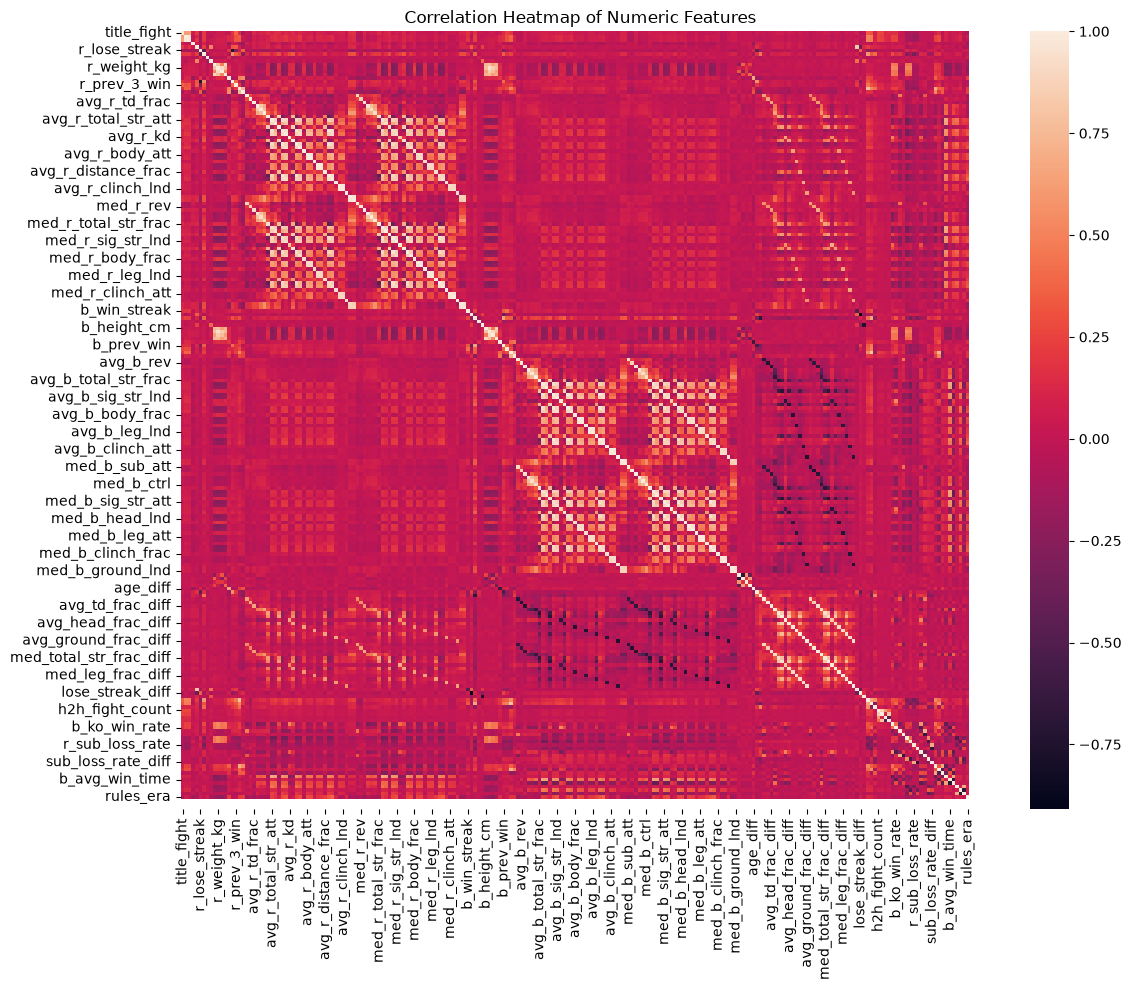

In [19]:
corr_matrix = full_ufc_selected.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix)

plt.title("Correlation Heatmap of Numeric Features")

plt.tight_layout()
plt.show()

## Rolling Window Size Search

Grid search over how much trailing history to train on and how far ahead to predict, scored with walk-forward folds rather than a single split.


In [20]:
# Pin the window between deliberate re-searches: the grid burns hours per
# retrain and re-choosing the window inside an experiment would confound its
# comparison. Set to None to re-run the search (do that alone, as its own
# EXPERIMENTS.md entry), or to (train_months, test_months) to pin.
BEST_WINDOW = (72, 6)

# The search must never see the final holdout -- selecting the window on
# holdout-period folds is leakage (this cell used to do exactly that).
search_df = full_ufc_selected[full_ufc_selected["date_d"] < HOLDOUT_START]

# Calculate available months
date1 = search_df["date_d"].max()
date2 = search_df["date_d"].min()

months_diff = (
    (date1.year - date2.year) * 12 +
    (date1.month - date2.month)
)

print(
    f"Available history: {months_diff} months "
    f"({date2.date()} → {date1.date()})"
)


# Rolling window combinations
# Each tuple = (training window months, testing window months)
train_options = [6, 12, 18, 24, 36, 48, 60, 72]
test_options = [6, 12, 18, 24]

combo_params = [
    (tr, te)
    for tr, te in product(train_options, test_options)
    if tr >= te and (tr + te) < months_diff
]


if BEST_WINDOW is not None:
    combination_eval = None
    print(f"Window pinned at {BEST_WINDOW} -- skipping grid search")
else:
    results = []

    for i, combination in enumerate(combo_params):

        remaining = len(combo_params) - i - 1

        print(
            f"\nCombination {i+1}/{len(combo_params)} "
            f"({remaining} remaining): {combination}"
        )

        preds = train_test_windows_by_month(
            search_df,
            train_months=combination[0],
            test_months=combination[1]
        )

        print(
            f"Generated folds: {len(preds)}"
        )

        if len(preds) == 0:
            print(f"Skipping {combination}: no predictions")
            continue

        cv_metrics = evaluate_cv_predictions(preds)

        results.append(
            [
                combination,
                len(preds),
                cv_metrics["Precision"],
                cv_metrics["Recall"],
                cv_metrics["F1"],
                cv_metrics["Accuracy"],
                cv_metrics["AUC"]
            ]
        )


    combination_eval = pd.DataFrame(
        results,
        columns=[
            "Combination",
            "Fold Number",
            "Test Precision",
            "Test Recall",
            "Test F1",
            "Test Accuracy",
            "Test AUC"
        ]
    )


Available history: 368 months (1995-04-07 → 2025-12-13)
Window pinned at (72, 6) -- skipping grid search


## Select Best Window and Build Training Set

Locks in the best-scoring window from the search above and builds the final training set from it.


In [21]:
if BEST_WINDOW is not None:
    best_train_months, best_test_months = BEST_WINDOW
else:
    combination_eval[["Train Months", "Test Months"]] = (
        pd.DataFrame(
            combination_eval["Combination"].tolist(),
            columns=["Train Months", "Test Months"],
            index=combination_eval.index
        )
    )
    # Best rolling window configuration (selected by AUC)
    top_combo = combination_eval.sort_values(
        by="Test AUC",
        ascending=False
    ).iloc[0]
    best_train_months = top_combo["Train Months"]
    best_test_months = top_combo["Test Months"]


# Latest available date
latest_date = full_ufc_selected["date_d"].max()


# The deployed models train on everything up to the holdout; the holdout
# length is a fixed evaluation budget (HOLDOUT_START, defined at feature
# selection), no longer coupled to the searched CV fold length.
train_end = HOLDOUT_START

train_start = train_end - pd.DateOffset(
    months=best_train_months
)


train_mask = (
    (full_ufc_selected["date_d"] >= train_start) &
    (full_ufc_selected["date_d"] < train_end)
)


# Mirror-augment so the final models cannot learn a red-corner bias
train_df = full_ufc_selected[train_mask].drop(columns=["date_d"])

train_df = pd.concat(
    [train_df, mirror_fights(train_df)],
    ignore_index=True
)

X_train = train_df.drop(columns=["r_win"])
y_train = train_df["r_win"]


print(
    f"Best window: "
    f"{best_train_months} months train / "
    f"{best_test_months} months test"
)

print(
    f"Training period: "
    f"{train_start.date()} → {train_end.date()}"
)


combination_eval.sort_values(by="Test AUC", ascending=False) if combination_eval is not None else None


Best window: 72 months train / 6 months test
Training period: 2020-01-18 → 2026-01-18


## Hyperparameter Tuning with Optuna

Searches XGBoost hyperparameters against the same walk-forward AUC used for window selection, so tuning and window choice are evaluated the same way.


In [22]:
# 1) Optuna study maximising rolling-window AUC -- genuinely distributed:
# both this machine and the laptop's eGPU connect to the SAME study via a
# shared PostgreSQL backend, so the TPE sampler is informed by every
# completed trial from EITHER machine in real time (not two blind searches
# merged after the fact, which is what the previous version of this cell did).
import subprocess, os, time, json, inspect, tempfile

# Postgres storage comes from the environment -- credentials never live in the
# repo (a plaintext DB password used to sit right here). Desktop shell profile
# sets OPTUNA_STORAGE_URL (localhost) and OPTUNA_WORKER_STORAGE_URL (the same
# DB as reachable FROM THE LAPTOP, i.e. the desktop's LAN address). Unset
# (e.g. cloud runs) -> in-process study: same search, no cross-machine sharing.
STORAGE_URL = os.environ.get("OPTUNA_STORAGE_URL")
# A stable name via OPTUNA_STUDY_NAME makes a died-and-relaunched run RESUME
# its completed trials from persistent storage (e.g. a local sqlite file) --
# cloud containers have a finite lifetime and a 10h+ CPU run doesn't fit in
# one. Unset -> timestamped fresh study as before (new data invalidates old
# trials; never reuse a study name across different experiments).
STUDY_NAME = (os.environ.get("OPTUNA_STUDY_NAME")
              or f"xgb_tuning_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}")
TRIAL_CAP = 100  # combined total across both machines

sampler = TPESampler(
    multivariate=True,
    n_startup_trials=20,
    seed=42
)

study = None
if STORAGE_URL:
    try:
        study = optuna.create_study(
            storage=STORAGE_URL,
            study_name=STUDY_NAME,
            sampler=sampler,
            direction="maximize",
            load_if_exists=True,
        )
    except Exception as e:
        # ponytail: Postgres configured but unreachable -- fall back to an
        # in-process study. Costs cross-machine trial sharing only.
        print(f"Postgres unreachable ({e}) -- running an in-process Optuna study instead.")
if study is None:
    if not STORAGE_URL:
        print("OPTUNA_STORAGE_URL not set -- in-process Optuna study (no laptop worker).")
    study = optuna.create_study(sampler=sampler, direction="maximize")

# Tune only on fights before the final holdout window so trial
# selection never sees the test period
tuning_df = full_ufc_selected[full_ufc_selected["date_d"] < train_end]

# --- Dispatch the laptop's eGPU (GTX 1660 SUPER) to join the SAME study ---
# ponytail: laptop is optional acceleration, never a dependency -- any
# failure below falls back to desktop-only tuning against the same study.
# Needs BOTH storage env vars: the worker connects to the desktop's Postgres
# by its LAN address. The worker driver lives in scripts/; the fold/mirror
# helpers are exported from the LIVE kernel definitions so the worker can
# never drift from the notebook's logic.
LAPTOP_HOST = "michael@10.1.1.242"
LAPTOP_KEY = os.path.expanduser("~/.ssh/laptop_g7")
REMOTE_DIR = "~/ufc_trial_worker"
WORKER_STORAGE_URL = os.environ.get("OPTUNA_WORKER_STORAGE_URL")

laptop_joined = False
if STORAGE_URL and WORKER_STORAGE_URL:
    try:
        scratch = tempfile.mkdtemp(prefix="ufc_tuning_")
        tuning_export_path = f"{scratch}/tuning_df_export.parquet"
        meta_export_path = f"{scratch}/tuning_meta.json"
        helpers_path = f"{scratch}/cell4_helpers.py"

        tuning_df.to_parquet(tuning_export_path, index=False)
        with open(meta_export_path, "w") as fh:
            json.dump({"best_train_months": int(best_train_months),
                       "best_test_months": int(best_test_months)}, fh)
        with open(helpers_path, "w") as fh:
            fh.write(
                "import numpy as np\n"
                "import pandas as pd\n"
                "from xgboost import XGBClassifier\n"
                "from sklearn.metrics import (precision_score, recall_score,\n"
                "    f1_score, accuracy_score, roc_auc_score)\n\n"
            )
            for fn in (mirror_fights, create_xgb_model,
                       train_test_windows_by_month, evaluate_cv_predictions):
                fh.write(inspect.getsource(fn) + "\n\n")

        subprocess.run(["ssh", "-i", LAPTOP_KEY, LAPTOP_HOST,
                        f"mkdir -p {REMOTE_DIR}"], check=True, timeout=15)
        subprocess.run(
            ["scp", "-i", LAPTOP_KEY, tuning_export_path, meta_export_path,
             helpers_path, "scripts/shared_study_worker.py",
             f"{LAPTOP_HOST}:{REMOTE_DIR}/"],
            check=True, timeout=120
        )

        remote_venv = "~/gpu_smoke_test_venv/bin/python"
        # rm -f: a stale done-file from a previous run would satisfy the wait
        # loop below instantly and strand a still-running worker.
        remote_cmd = (
            f"cd {REMOTE_DIR} && rm -f laptop_shared_done && "
            f"OPTUNA_STORAGE_URL='{WORKER_STORAGE_URL}' "
            f"CUDA_DEVICE_ORDER=PCI_BUS_ID setsid nohup {remote_venv} "
            f"shared_study_worker.py tuning_df_export.parquet tuning_meta.json {STUDY_NAME} {TRIAL_CAP} "
            f"cuda:1 43 laptop_shared_done < /dev/null > worker.log 2>&1 &"
        )
        # -f backgrounds the ssh client itself right after auth, before running the
        # remote command -- plain "nohup ... &" alone leaves ssh hanging waiting on
        # the channel even with output redirected (confirmed via smoke test).
        subprocess.run(["ssh", "-f", "-i", LAPTOP_KEY, LAPTOP_HOST, remote_cmd], check=True, timeout=15)
        laptop_joined = True
        print(f"Laptop eGPU joined shared study '{STUDY_NAME}' (combined cap: {TRIAL_CAP} trials)...")
    except (subprocess.CalledProcessError, subprocess.TimeoutExpired, OSError) as e:
        print(f"Laptop unreachable ({e}) -- continuing desktop-only against '{STUDY_NAME}' "
              f"(cap: {TRIAL_CAP} trials).")
else:
    print("Worker storage env vars not both set -- desktop-only tuning.")


def objective(trial):
    """Optuna objective: rolling-window cross-validated AUC.

    Suggests an XGBoost parameter set, evaluates it with the same
    monthly rolling-window scheme used for window selection, and
    returns the pooled out-of-sample AUC for Optuna to maximise.

    Parameters
    ----------
    trial : optuna.trial.Trial
        The current Optuna trial.

    Returns
    -------
    float
        Pooled test AUC across the rolling-window folds.
    """
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "verbosity": 0,
        "random_state": 42,

        "max_depth": trial.suggest_int(
            "max_depth",
            1,
            6
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.002,
            0.05,
            log=True
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators",
            400,
            1600
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            50
        ),

        "gamma": trial.suggest_float(
            "gamma",
            1e-8,
            10,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "enable_categorical": True,
        "tree_method": "hist",
        "device": DEVICE  # probed at startup; the laptop worker probes its own device
    }


    preds = train_test_windows_by_month(
        tuning_df,
        train_months=best_train_months,
        test_months=best_test_months,
        model_params=params
    )


    cv_metrics = evaluate_cv_predictions(
        preds,
        verbose=False
    )


    return cv_metrics["AUC"]


def stop_when_enough(study, trial):
    """Global stop once the SHARED study (both machines combined) hits the cap.

    A small overshoot (typically +1 trial) is possible if both machines
    check right around the boundary at the same time -- negligible at this
    scale (100 trials) and not worth extra coordination overhead to avoid.
    """
    n_complete = len([t for t in study.get_trials(deepcopy=False)
                       if t.state == TrialState.COMPLETE])
    if n_complete >= TRIAL_CAP:
        study.stop()


# Skip entirely when a resumed study already hit the cap -- the callback
# only fires AFTER a trial completes, which would waste one full trial.
n_done = len([t for t in study.get_trials(deepcopy=False)
              if t.state == TrialState.COMPLETE])
if n_done < TRIAL_CAP:
    study.optimize(
        objective,
        n_trials=None,
        callbacks=[stop_when_enough],
    )
else:
    print(f"Study already has {n_done} complete trials (cap {TRIAL_CAP}) -- resuming past tuning.")

# --- wait for the laptop worker to also see the cap and stop (only if it joined) ---
if laptop_joined:
    print("Waiting for laptop eGPU worker to finish...")
    wait_start = time.time()
    while True:
        check = subprocess.run(
            ["ssh", "-i", LAPTOP_KEY, LAPTOP_HOST, f"test -f {REMOTE_DIR}/laptop_shared_done"],
            timeout=30
        )
        if check.returncode == 0:
            break
        time.sleep(30)
        print(f"  ...still waiting ({time.time() - wait_start:.0f}s elapsed)")

completed = [t for t in study.trials if t.state == TrialState.COMPLETE]
print(f"Shared study '{STUDY_NAME}' complete: {len(completed)} trials total "
      f"(desktop + laptop combined). Best AUC: {study.best_value:.4f}")
print("Best params:", study.best_params)


fig = plot_optimization_history(study)
fig.show()

[I 2026-08-05 01:09:25,538] Using an existing study with name 'exp4_shrinkage' instead of creating a new one.


Worker storage env vars not both set -- desktop-only tuning.


[I 2026-08-05 01:12:14,157] Trial 88 finished with value: 0.623504115207748 and parameters: {'max_depth': 6, 'learning_rate': 0.040500588429208666, 'n_estimators': 1112, 'min_child_weight': 50, 'gamma': 2.2952076433586566e-07, 'subsample': 0.6434522396100699, 'colsample_bytree': 0.6912010865268139, 'reg_alpha': 0.133679451636192, 'reg_lambda': 0.020988673113956538}. Best is trial 66 with value: 0.6171233714472758.


[I 2026-08-05 01:16:09,105] Trial 89 finished with value: 0.623622883932586 and parameters: {'max_depth': 5, 'learning_rate': 0.04826507161901179, 'n_estimators': 1527, 'min_child_weight': 33, 'gamma': 1.4490037967362699e-08, 'subsample': 0.649291962522966, 'colsample_bytree': 0.8129441321123614, 'reg_alpha': 0.020378696945411837, 'reg_lambda': 0.18575594082912628}. Best is trial 66 with value: 0.6171233714472758.


[I 2026-08-05 01:19:43,297] Trial 90 finished with value: 0.6160380518593316 and parameters: {'max_depth': 4, 'learning_rate': 0.04489024556278377, 'n_estimators': 1463, 'min_child_weight': 42, 'gamma': 1.7356725475961344e-06, 'subsample': 0.611447109955162, 'colsample_bytree': 0.7729979918986696, 'reg_alpha': 0.00033053800296136446, 'reg_lambda': 1.6174930367762528e-05}. Best is trial 90 with value: 0.6160380518593316.


...

[I 2026-08-05 01:45:05,983] Trial 97 finished with value: 0.6164685450518476 and parameters: {'max_depth': 5, 'learning_rate': 0.04378763927532095, 'n_estimators': 1585, 'min_child_weight': 45, 'gamma': 2.942339826908734e-07, 'subsample': 0.6023326354614154, 'colsample_bytree': 0.8804007434565435, 'reg_alpha': 2.89957246083956e-06, 'reg_lambda': 0.0005798507556276325}. Best is trial 90 with value: 0.6160380518593316.


[I 2026-08-05 01:48:30,571] Trial 98 finished with value: 0.6200938752448866 and parameters: {'max_depth': 5, 'learning_rate': 0.04782946044185429, 'n_estimators': 1140, 'min_child_weight': 44, 'gamma': 2.1396539195879593e-06, 'subsample': 0.6085711148243632, 'colsample_bytree': 0.8910946227629715, 'reg_alpha': 9.360613603553757e-05, 'reg_lambda': 0.00017342749112517143}. Best is trial 90 with value: 0.6160380518593316.


[I 2026-08-05 01:53:11,166] Trial 99 finished with value: 0.6268398554204476 and parameters: {'max_depth': 5, 'learning_rate': 0.032442356383968474, 'n_estimators': 1576, 'min_child_weight': 35, 'gamma': 9.158698277853477e-06, 'subsample': 0.6377960146712203, 'colsample_bytree': 0.9378711568863793, 'reg_alpha': 0.00011567263023670805, 'reg_lambda': 0.00016426807464789439}. Best is trial 90 with value: 0.6160380518593316.


[I 2026-08-05 01:55:52,923] Trial 100 finished with value: 0.6268780782400268 and parameters: {'max_depth': 3, 'learning_rate': 0.031758437994457385, 'n_estimators': 1415, 'min_child_weight': 47, 'gamma': 2.7763375587374487e-07, 'subsample': 0.6088061432138945, 'colsample_bytree': 0.771838844568436, 'reg_alpha': 4.787883207230367e-07, 'reg_lambda': 6.980168921276152e-05}. Best is trial 90 with value: 0.6160380518593316.


Shared study 'exp4_shrinkage' complete: 100 trials total (desktop + laptop combined). Best AUC: 0.6160
Best params: {'max_depth': 4, 'learning_rate': 0.04489024556278377, 'n_estimators': 1463, 'min_child_weight': 42, 'gamma': 1.7356725475961344e-06, 'subsample': 0.611447109955162, 'colsample_bytree': 0.7729979918986696, 'reg_alpha': 0.00033053800296136446, 'reg_lambda': 1.6174930367762528e-05}


## Hyperparameter Tuning with Optuna (LightGBM)

Same search, same rolling-window CV harness as the XGBoost tuning above, but for LightGBM -- so the blend-weight choice in the Ensemble cell below reflects both models' real potential rather than a tuned XGBoost against an untuned LightGBM.

In [23]:
# Tune LightGBM with the same rolling-window CV harness and search budget
# used for XGBoost (Cell above), so the eventual blend-weight choice in the
# Ensemble cell reflects both models' real potential rather than comparing
# a 100-trial-tuned XGBoost against LightGBM's untuned defaults.
lgbm_sampler = TPESampler(
    multivariate=True,
    n_startup_trials=20,
    seed=42
)

# Same resume mechanism as the XGBoost study above: with OPTUNA_STORAGE_URL
# and a stable OPTUNA_STUDY_NAME set, a relaunched run reloads its completed
# trials instead of starting over. In-process (no storage) otherwise.
_lgbm_storage = os.environ.get("OPTUNA_STORAGE_URL")
_lgbm_name = os.environ.get("OPTUNA_STUDY_NAME")
if _lgbm_storage and _lgbm_name:
    try:
        lgbm_study = optuna.create_study(
            storage=_lgbm_storage, study_name=f"{_lgbm_name}_lgbm",
            sampler=lgbm_sampler, direction="maximize", load_if_exists=True)
    except Exception as e:
        print(f"LGBM storage unreachable ({e}) -- in-process study instead.")
        lgbm_study = optuna.create_study(sampler=lgbm_sampler, direction="maximize")
else:
    lgbm_study = optuna.create_study(sampler=lgbm_sampler, direction="maximize")


def lgbm_objective(trial):
    """Optuna objective: rolling-window cross-validated AUC for LightGBM.

    Mirrors the XGBoost objective above -- same tuning_df, same walk-forward
    CV scheme, same AUC target -- swapping in LightGBM's hyperparameters and
    ``model_class=LGBMClassifier``. LightGBM stays CPU-only (a GPU
    build isn't worth the packaging); XGBoost uses the probed DEVICE.

    Parameters
    ----------
    trial : optuna.trial.Trial
        The current Optuna trial.

    Returns
    -------
    float
        Pooled test AUC across the rolling-window folds.
    """
    params = {
        "objective": "binary",
        "random_state": 42,
        "verbosity": -1,

        "num_leaves": trial.suggest_int(
            "num_leaves",
            7,
            255
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.002,
            0.05,
            log=True
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators",
            400,
            1600
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            100
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),
        # Without a bagging frequency LightGBM silently ignores subsample --
        # the whole search dimension was inert before this
        "subsample_freq": 1,

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),
    }


    preds = train_test_windows_by_month(
        tuning_df,
        train_months=best_train_months,
        test_months=best_test_months,
        model_params=params,
        model_class=LGBMClassifier
    )


    cv_metrics = evaluate_cv_predictions(
        preds,
        verbose=False
    )


    return cv_metrics["AUC"]

_lgbm_done = len([t for t in lgbm_study.get_trials(deepcopy=False)
                  if t.state == TrialState.COMPLETE])
if _lgbm_done < 100:
    lgbm_study.optimize(lgbm_objective, n_trials=100 - _lgbm_done)
else:
    print(f"LGBM study already has {_lgbm_done} complete trials -- resuming past tuning.")


print("Best LGBM AUC:", lgbm_study.best_value)
print("Best LGBM params:", lgbm_study.best_params)

[I 2026-08-05 01:55:55,248] A new study created in RDB with name: exp4_shrinkage_lgbm


[I 2026-08-05 01:59:57,982] Trial 0 finished with value: 0.6257635703171313 and parameters: {'num_leaves': 100, 'learning_rate': 0.042664981476167235, 'n_estimators': 1279, 'min_child_samples': 62, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 0.6257635703171313.


[I 2026-08-05 02:01:17,939] Trial 1 finished with value: 0.6431644741825702 and parameters: {'num_leaves': 156, 'learning_rate': 0.019537679506141502, 'n_estimators': 424, 'min_child_samples': 98, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07}. Best is trial 1 with value: 0.6431644741825702.


[I 2026-08-05 02:07:32,373] Trial 2 finished with value: 0.6431403590582175 and parameters: {'num_leaves': 82, 'learning_rate': 0.010829490041084236, 'n_estimators': 918, 'min_child_samples': 32, 'subsample': 0.8447411578889518, 'colsample_bytree': 0.6557975442608167, 'reg_alpha': 4.258943089524393e-06, 'reg_lambda': 1.9826980964985924e-05}. Best is trial 1 with value: 0.6431644741825702.


[I 2026-08-05 02:10:35,259] Trial 3 finished with value: 0.6344259036743249 and parameters: {'num_leaves': 120, 'learning_rate': 0.025041416170325806, 'n_estimators': 639, 'min_child_samples': 54, 'subsample': 0.836965827544817, 'colsample_bytree': 0.6185801650879991, 'reg_alpha': 0.0029369981104377003, 'reg_lambda': 3.425445902633376e-07}. Best is trial 1 with value: 0.6431644741825702.


...

[I 2026-08-05 07:22:04,739] Trial 96 finished with value: 0.6561958148097442 and parameters: {'num_leaves': 15, 'learning_rate': 0.002903849032201328, 'n_estimators': 847, 'min_child_samples': 61, 'subsample': 0.8242576609783437, 'colsample_bytree': 0.6154095235944728, 'reg_alpha': 0.0022099216237894616, 'reg_lambda': 0.06647731264611832}. Best is trial 58 with value: 0.6573950384000344.


[I 2026-08-05 07:24:18,196] Trial 97 finished with value: 0.654392601174066 and parameters: {'num_leaves': 32, 'learning_rate': 0.0024846110516731587, 'n_estimators': 558, 'min_child_samples': 26, 'subsample': 0.6115024610318891, 'colsample_bytree': 0.7559255916886428, 'reg_alpha': 0.033030873187775506, 'reg_lambda': 5.317603082996596}. Best is trial 58 with value: 0.6573950384000344.


[I 2026-08-05 07:25:58,489] Trial 98 finished with value: 0.6568119666613618 and parameters: {'num_leaves': 7, 'learning_rate': 0.0023645279129844545, 'n_estimators': 1171, 'min_child_samples': 21, 'subsample': 0.9685321686281108, 'colsample_bytree': 0.6590316377840922, 'reg_alpha': 0.10896005580118598, 'reg_lambda': 0.028504660447094998}. Best is trial 58 with value: 0.6573950384000344.


[I 2026-08-05 07:26:52,222] Trial 99 finished with value: 0.6558839166019774 and parameters: {'num_leaves': 12, 'learning_rate': 0.0022536816733434474, 'n_estimators': 403, 'min_child_samples': 23, 'subsample': 0.6529095196546609, 'colsample_bytree': 0.7334808613661351, 'reg_alpha': 3.2932107293055104, 'reg_lambda': 0.0006857716587301913}. Best is trial 58 with value: 0.6573950384000344.


Best LGBM AUC: 0.6573950384000344
Best LGBM params: {'num_leaves': 9, 'learning_rate': 0.002050459520884858, 'n_estimators': 1145, 'min_child_samples': 44, 'subsample': 0.6813481269470523, 'colsample_bytree': 0.7482697981450692, 'reg_alpha': 0.04505995332362956, 'reg_lambda': 3.102885044096528}


## Final Holdout Test Split

Carves out the most recent fights into a validation slice (for threshold/blend tuning) and a final test slice the model never sees until scoring.


In [24]:
# Split the holdout period in half: the first half is a validation set
# used only to pick the decision threshold, the second half is the final
# untouched test set
test_start = train_end
holdout_mid = test_start + (latest_date - test_start) / 2

val_mask = (
    (full_ufc_selected["date_d"] >= test_start) &
    (full_ufc_selected["date_d"] < holdout_mid)
)

test_mask = (
    (full_ufc_selected["date_d"] >= holdout_mid) &
    (full_ufc_selected["date_d"] <= latest_date)
)

X_val = full_ufc_selected[val_mask].drop(columns=["r_win", "date_d"])
y_val = full_ufc_selected[val_mask]["r_win"]

X_test = full_ufc_selected[test_mask].drop(columns=["r_win", "date_d"])
y_test = full_ufc_selected[test_mask]["r_win"]

print(f"Validation: {val_mask.sum()} fights "
      f"({test_start.date()} → {holdout_mid.date()})")
print(f"Test:       {test_mask.sum()} fights "
      f"({holdout_mid.date()} → {latest_date.date()})")


Validation: 120 fights (2026-01-18 → 2026-04-18)
Test:       110 fights (2026-04-18 → 2026-07-18)


## Ensemble of Top Trials

Retrains the top Optuna trials plus an Optuna-tuned LightGBM model, and blends them at the mixing weight that scores best on validation.


In [25]:
# Keep the top 3 trials from the SHARED study (study.trials already reflects
# both machines' contributions -- no manual merge needed with the distributed
# Postgres-backed study) -- the former top 10 were near-clones (identical AUC
# to 3 dp), so 3 gives the same variance smoothing at a third of the cost --
# and add a tuned LightGBM model for genuine diversity.
top_trials = sorted(
    [t for t in study.trials if t.state == TrialState.COMPLETE],
    key=lambda t: t.value,
    reverse=True
)[:3]

models = []
for i, t in enumerate(top_trials):
    params = t.params.copy()
    params.update({
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "verbosity": 0,
        "enable_categorical": True,
        "tree_method": "hist",
        "device": DEVICE,
        "random_state": 42
    })
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    models.append(model)
    print(f"XGB {i + 1} of {len(top_trials)} trained")

lgbm = LGBMClassifier(
    **lgbm_study.best_params,
    objective="binary",
    random_state=42,
    verbosity=-1,
    subsample_freq=1,  # fixed (not searched), so best_params won't carry it
)
lgbm.fit(X_train, y_train)
print(f"LGBM trained (tuned, CV AUC {lgbm_study.best_value:.3f})")

# Pick the LGBM blend weight on validation AUC (3 candidates only, so the
# validation reuse is mild)
xgb_val = np.mean([m.predict_proba(X_val)[:, 1] for m in models], axis=0)
lgb_val = lgbm.predict_proba(X_val)[:, 1]
lgbm_weight = max(
    (0.0, 0.25, 0.5),
    key=lambda w: roc_auc_score(y_val, (1 - w) * xgb_val + w * lgb_val)
)
print(f"LGBM blend weight: {lgbm_weight} "
      f"(XGB-only val AUC {roc_auc_score(y_val, xgb_val):.3f}, "
      f"LGBM-only val AUC {roc_auc_score(y_val, lgb_val):.3f})")


def blend_proba(X):
    """Ensemble probability that the red-corner fighter wins."""
    xgb_p = np.mean([m.predict_proba(X)[:, 1] for m in models], axis=0)
    lgb_p = lgbm.predict_proba(X)[:, 1]
    return (1 - lgbm_weight) * xgb_p + lgbm_weight * lgb_p


y_proba_train = blend_proba(X_train)
y_proba_val = blend_proba(X_val)
y_proba_test = blend_proba(X_test)

preds = (y_proba_test >= 0.5).astype(int)
print(classification_report(y_test, preds))
print(f"Blended ensemble test AUC: {roc_auc_score(y_test, y_proba_test):.3f}")


XGB 1 of 3 trained


XGB 2 of 3 trained


XGB 3 of 3 trained


LGBM trained (tuned, CV AUC 0.657)
LGBM blend weight: 0.5 (XGB-only val AUC 0.720, LGBM-only val AUC 0.729)


              precision    recall  f1-score   support

           0       0.60      0.56      0.58        50
           1       0.65      0.68      0.67        60

    accuracy                           0.63       110
   macro avg       0.62      0.62      0.62       110
weighted avg       0.63      0.63      0.63       110

Blended ensemble test AUC: 0.682


## Top Trial Parameters

Every completed Optuna trial, sorted by score, for inspecting what the search actually found.


In [26]:
# Convert Optuna trials to DataFrame
results_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))

# Sort by highest AUC
results_df = results_df.sort_values(by="value", ascending=False)

# Display top 20 trials
results_df.head(20)

,number,value,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
7,7,0.656847,0.994755,1.658719e-01,0.004940,3,8,1051,8.916675e-02,6.143857e-07,0.629820,COMPLETE
2,2,0.656789,0.782428,4.258943e-06,0.005107,3,7,1134,1.165692e-01,6.267063e-07,0.746545,COMPLETE
9,9,0.656022,0.855023,8.445977e-06,0.005802,4,16,476,9.658611e-01,1.778011e-04,0.891842,COMPLETE
15,15,0.655185,0.700713,5.572355e+00,0.010624,2,19,1244,2.987009e-04,5.103931e-06,0.984979,COMPLETE
4,4,0.653875,0.613755,1.254134e-07,0.002739,2,23,1221,1.527157e+00,2.133142e-06,0.798071,COMPLETE
5,5,0.653148,0.910053,4.609885e-07,0.005455,4,28,1024,2.854240e+00,1.130957e+00,0.987834,COMPLETE
10,10,0.651712,0.809093,8.683696e-02,0.019866,1,29,1313,7.044808e-05,1.693449e-08,0.797518,COMPLETE
3,3,0.651568,0.979554,3.425446e-07,0.013464,4,31,455,4.905557e+00,1.886150e-01,0.626021,COMPLETE
16,16,0.651514,0.963306,2.906088e-08,0.002252,2,26,1132,1.432376e-06,2.013974e-07,0.711459,COMPLETE
12,12,0.650043,0.853362,2.329587e+00,0.002562,2,9,747,6.968596e-01,1.710207e-01,0.923248,COMPLETE


## Ensemble Metrics

Train/test precision, recall, F1, accuracy and AUC for the blended ensemble at the neutral 0.5 threshold.


In [27]:
# Blended ensemble at the 0.5 operating point (the decision threshold —
# see the next section for why it is fixed rather than tuned).
for name, y_true, proba in (
    ("Train", y_train, y_proba_train),
    ("Test", y_test, y_proba_test),
):
    preds = (proba >= 0.5).astype(int)
    print(f"{name} Metrics (Blended Ensemble @0.5)")
    print(f" Precision: {precision_score(y_true, preds, average='weighted'):.3f}")
    print(f" Recall:    {recall_score(y_true, preds, average='weighted'):.3f}")
    print(f" F1 Score:  {f1_score(y_true, preds, average='weighted'):.3f}")
    print(f" Accuracy:  {accuracy_score(y_true, preds):.3f}")
    print(f" AUC:       {roc_auc_score(y_true, proba):.3f}")
    print()


Train Metrics (Blended Ensemble @0.5)
 Precision: 0.680
 Recall:    0.680
 F1 Score:  0.680
 Accuracy:  0.680
 AUC:       0.752

Test Metrics (Blended Ensemble @0.5)
 Precision: 0.626
 Recall:    0.627
 F1 Score:  0.626
 Accuracy:  0.627
 AUC:       0.682



## Probability Calibration

Fits Platt scaling on pooled walk-forward CV out-of-fold predictions (not the small validation slice, which overfits -- see Threshold Selection) so the displayed confidence tracks real win frequency. The decision rule (winner @ threshold 0.5) is unaffected: a dedicated experiment confirmed retuning the threshold on calibrated scores doesn't beat the raw score, so calibration is for display only.

In [28]:
# Platt scaling fit on pooled walk-forward OOF predictions -- never the
# small validation slice, which overfits (see Threshold Selection's
# ponytail: note, and the July 2026 run where that cost 6 points of test
# accuracy). Reuses the same rolling-window harness as tuning, just run
# once more per final model instead of hundreds of Optuna trials.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss


def _pooled_oof(model_params, model_class=XGBClassifier):
    preds = train_test_windows_by_month(
        tuning_df, train_months=best_train_months, test_months=best_test_months,
        model_params=model_params, model_class=model_class
    )
    df = pd.concat([
        pd.DataFrame({"index": f["index"], "y_true": f["y_true"],
                      "y_proba": f["y_proba"], "test_end": f["test_end"]})
        for f in preds
    ], ignore_index=True)
    return (df.sort_values("test_end")
              .drop_duplicates(subset="index", keep="last")
              .set_index("index").sort_index())


xgb_oof = [
    _pooled_oof({**t.params, "objective": "binary:logistic", "eval_metric": "logloss",
                 "verbosity": 0, "enable_categorical": True, "tree_method": "hist",
                 "device": DEVICE, "random_state": 42})
    for t in top_trials
]
lgbm_oof = _pooled_oof(
    {**lgbm_study.best_params, "objective": "binary", "random_state": 42,
     "verbosity": -1, "subsample_freq": 1},
    model_class=LGBMClassifier
)

oof_y = xgb_oof[0]["y_true"]
xgb_oof_proba = pd.concat([o["y_proba"] for o in xgb_oof], axis=1).mean(axis=1)
oof_proba = (1 - lgbm_weight) * xgb_oof_proba + lgbm_weight * lgbm_oof["y_proba"]

# Anchor the calibrator so raw=0.5 always maps to calibrated=0.5 -- fit only
# the slope, on the score centered at 0.5 (fit_intercept=False), so the
# decision rule (raw @ best_th) and the displayed confidence can never
# disagree about who's favored. predict.py centers the same way before
# calling .predict_proba. An unconstrained intercept was tried first and
# broke this: it mapped raw=0.5 to calibrated=0.61, so any fight with raw
# in [0.41, 0.50) was decided one way but displayed favoring the other.
calibrator = LogisticRegression(fit_intercept=False)
calibrator.fit((oof_proba.values - 0.5).reshape(-1, 1), oof_y.values)

# self-check: calibration must not make the pooled OOF predictions less
# reliable than the raw score (lower Brier = better), and must preserve
# the raw@0.5 decision boundary exactly
raw_brier = brier_score_loss(oof_y, oof_proba)
calibrated_brier = brier_score_loss(
    oof_y, calibrator.predict_proba((oof_proba.values - 0.5).reshape(-1, 1))[:, 1]
)
crossing_check = calibrator.predict_proba([[0.0]])[0, 1]
print(f"Pooled OOF ({len(oof_y)} fights) Brier score: "
      f"raw={raw_brier:.4f}  calibrated={calibrated_brier:.4f}")
print(f"Calibrated value at raw=0.5 (must be exactly 0.5): {crossing_check:.6f}")
assert abs(crossing_check - 0.5) < 1e-9
assert calibrated_brier <= raw_brier + 0.01, (
    "Calibration made pooled OOF probabilities less reliable -- don't persist it"
)


# Exported with the ensemble: the pooled OOF predictions carry fight identity
# so the NEXT run's Paired Comparison cell can align the two models on ~6k
# walk-forward fights instead of the ~110-fight test set (which has almost no
# statistical power -- see EXPERIMENTS.md protocol).
oof_export = full_ufc_engineered.loc[
    oof_proba.index, ["r_fighter", "b_fighter", "date_d"]
].assign(y=oof_y.values, proba=oof_proba.values)
print(f"Pooled OOF for export: {len(oof_export)} fights")


Pooled OOF (7869 fights) Brier score: raw=0.2250  calibrated=0.2245
Calibrated value at raw=0.5 (must be exactly 0.5): 0.500000
Pooled OOF for export: 7869 fights


## Threshold Selection

Diagnostic sweep of the win/loss cutoff across thresholds. The deployed threshold stays fixed at 0.5 (see the cell for why) rather than being fit to this sweep.


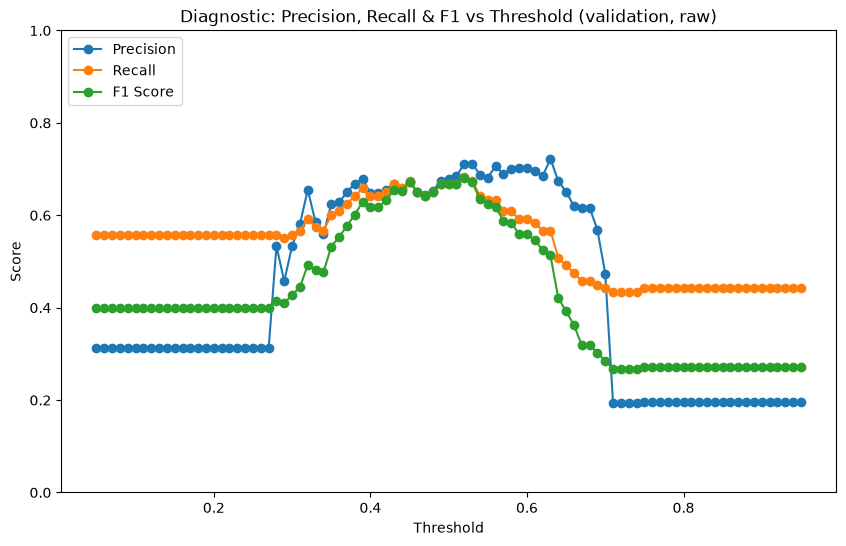

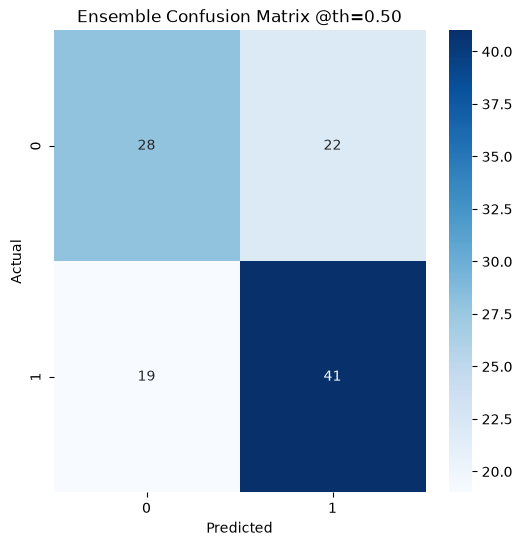

diff_pairs verified for 46 diff features
Saved ensemble.joblib


In [29]:
# ——— Decision layer: fixed 0.5 threshold on raw blended probabilities ——— #
# Training data is mirror-augmented to exactly 50/50, so 0.5 is the neutral
# cutoff with zero fitted parameters. Fitting a calibrator + threshold to the
# 120-fight validation slice overfits: in the July 2026 run it cost 6 points
# of test accuracy (0.618 -> 0.555).
# ponytail: if calibrated probabilities are ever needed (e.g. comparing to
# betting odds), fit Platt + threshold on pooled rolling-window out-of-fold
# predictions, never on the small validation slice.
best_th = 0.5

# ——— Diagnostic only: threshold sensitivity on validation ——— #
thresholds = np.arange(0.05, 0.96, 0.01)
precisions, recalls, f1s = [], [], []
for th in thresholds:
    preds = (y_proba_val >= th).astype(int)
    precisions.append(precision_score(y_val, preds, average='weighted'))
    recalls.append(recall_score(y_val, preds, average='weighted'))
    f1s.append(f1_score(y_val, preds, average='weighted'))
f1s = np.array(f1s)

plt.figure(figsize=(10, 6))
# Same marker/linestyle for all three, distinguished by colour only -- one
# axis is enough now that the styling no longer implies F1 is a different
# kind of quantity from precision/recall (all three already live in [0, 1]).
for values, label, color in (
    (precisions, "Precision", "tab:blue"),
    (recalls, "Recall", "tab:orange"),
    (f1s, "F1 Score", "tab:green"),
):
    plt.plot(thresholds, values, label=label, marker="o", color=color)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.title("Diagnostic: Precision, Recall & F1 vs Threshold (validation, raw)")
plt.show()

# ——— Confusion matrix at the 0.5 operating point ——— #
# (test metrics at 0.5 are printed in the Ensemble Metrics cell above)
y_pred_test = (y_proba_test >= best_th).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Ensemble Confusion Matrix @th={best_th:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ——— Persist the predictor ——— #
import joblib
# Exact diff -> (r_col, b_col) source map, verified numerically against the
# engineered frame so serving never guesses source names again (substring
# guessing once silently zero-filled 25 features in production).
import importlib
import predict as _serving
importlib.reload(_serving)
diff_pairs = _serving.build_diff_pairs(
    list(X_train.columns), full_ufc_engineered.columns
)
for _d, (_r, _b) in diff_pairs.items():
    _lhs = full_ufc_engineered[_d].astype(float).to_numpy()
    _rhs = (full_ufc_engineered[_r].astype(float)
            - full_ufc_engineered[_b].astype(float)).to_numpy()
    _bad = ~np.isclose(_lhs, _rhs, equal_nan=True)
    assert not _bad.any(), f"{_d} != {_r} - {_b} on {_bad.sum()} rows"
print(f"diff_pairs verified for {len(diff_pairs)} diff features")

joblib.dump(
    {"models": models, "lgbm": lgbm, "lgbm_weight": lgbm_weight,
     "best_th": best_th, "calibrator": calibrator,
     "feature_names": list(X_train.columns), "dtypes": X_train.dtypes,
     "diff_pairs": diff_pairs,
     # provenance + the pooled OOF for high-power paired comparisons
     "train_end": train_end, "data_max_date": latest_date,
     "oof": oof_export},
    "ensemble.joblib"
)
print("Saved ensemble.joblib")


## Test Set Stability Check

How much the single test-set accuracy could plausibly vary by chance (CLT confidence interval), and whether performance holds steady across months or was one lucky/unlucky stretch.


Pooled test accuracy: 0.627  (n=110)
95% CI (CLT):        [0.537, 0.718]

  month  n  accuracy
2026-04  8  0.375000
2026-05 45  0.488889
2026-06 36  0.777778
2026-07 21  0.761905

Batch accuracy: 0.601 +/- 0.201 over 4 monthly batches


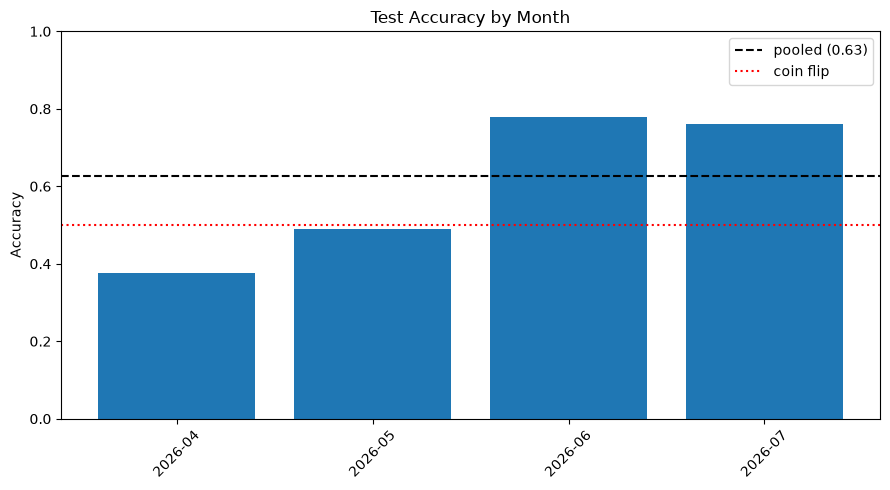

In [30]:
# The 0.5-threshold test metrics above come from ONE 110-fight batch — too
# small to trust on its own. Two complementary checks:
#
# 1) CLT confidence interval on the pooled accuracy: quantifies how much a
#    single-batch estimate could plausibly be off by, assuming performance
#    is stable throughout the period.
# 2) Split the same 110 fights into monthly batches and compare: reveals
#    whether performance is actually stable, or drifting/unstable across
#    the period (something the CLT interval alone can't show, since it
#    assumes one fixed underlying accuracy).
n = len(y_test)
p_hat = accuracy_score(y_test, (y_proba_test >= best_th).astype(int))
se = np.sqrt(p_hat * (1 - p_hat) / n)
ci_low, ci_high = p_hat - 1.96 * se, p_hat + 1.96 * se
print(f"Pooled test accuracy: {p_hat:.3f}  (n={n})")
print(f"95% CI (CLT):        [{ci_low:.3f}, {ci_high:.3f}]")
print()

# ——— Monthly batches over the same test fights ——— #
test_dates = pd.to_datetime(full_ufc_selected.loc[y_test.index, "date_d"])
batch = test_dates.dt.to_period("M")

rows = []
for period, idx in y_test.groupby(batch).groups.items():
    pos = [y_test.index.get_loc(i) for i in idx]
    y_true_b = y_test.loc[idx]
    y_proba_b = y_proba_test[pos]
    y_pred_b = (y_proba_b >= best_th).astype(int)
    rows.append({
        "month": str(period),
        "n": len(idx),
        "accuracy": accuracy_score(y_true_b, y_pred_b),
    })

batch_df = pd.DataFrame(rows).sort_values("month")
print(batch_df.to_string(index=False))
print()
print(f"Batch accuracy: {batch_df['accuracy'].mean():.3f} "
      f"+/- {batch_df['accuracy'].std():.3f} over {len(batch_df)} monthly batches")

plt.figure(figsize=(9, 5))
plt.bar(batch_df["month"], batch_df["accuracy"])
plt.axhline(p_hat, color="black", linestyle="--", label=f"pooled ({p_hat:.2f})")
plt.axhline(0.5, color="red", linestyle=":", label="coin flip")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Test Accuracy by Month")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Paired Comparison vs. Baseline (McNemar)

Statistically compares this run's model against a frozen snapshot of the previous run, on the exact same fights, to tell real improvement from noise.


In [31]:
# Paired comparison against the snapshotted baseline, two ways:
#   1) SANITY: the ~110-fight test set (almost no statistical power -- with
#      ~20 discordant fights only huge effects reach p<0.05);
#   2) PRIMARY GATE: pooled walk-forward OOF (~6k fights), aligned by fight
#      identity with the baseline's exported OOF. This is the number the
#      EXPERIMENTS.md accept/revert decision reads.
# ponytail: requires ensemble_baseline.joblib — a snapshot taken before
# this run started. Re-snapshot (cp ensemble.joblib ensemble_baseline.joblib)
# before the next experiment you want to compare against.
import joblib
from statsmodels.stats.contingency_tables import mcnemar
from predict import blend_proba as _blend_proba_generic

import os

if not os.path.exists("ensemble_baseline.joblib"):
    # Headless safety: the baseline snapshot is gitignored and absent on
    # fresh clones/cloud runs -- skip the comparison instead of aborting
    # nbconvert before the parquet export. Snapshot one before each
    # experiment: cp ensemble.joblib ensemble_baseline.joblib
    print("No ensemble_baseline.joblib -- skipping paired comparison.")
else:
    baseline = joblib.load("ensemble_baseline.joblib")
    if "train_end" in baseline:
        # A baseline trained past this run's test start would make the paired
        # test-set comparison meaningless
        assert pd.Timestamp(baseline["train_end"]) <= test_start, (
            "baseline train_end is inside this run's holdout -- invalid comparison"
        )
    X_test_baseline = X_test.reindex(columns=baseline["feature_names"])
    X_test_baseline = X_test_baseline.astype(baseline["dtypes"].to_dict())

    baseline_proba = _blend_proba_generic(
        X_test_baseline, baseline["models"], baseline["lgbm"], baseline["lgbm_weight"]
    )
    baseline_correct = (baseline_proba >= baseline["best_th"]).astype(int) == y_test.values
    new_correct = ((y_proba_test >= best_th).astype(int) == y_test.values)

    both_right = int((baseline_correct & new_correct).sum())
    both_wrong = int((~baseline_correct & ~new_correct).sum())
    new_fixes = int((new_correct & ~baseline_correct).sum())
    new_breaks = int((baseline_correct & ~new_correct).sum())

    print(f"Baseline accuracy: {baseline_correct.mean():.3f}")
    print(f"This run accuracy: {new_correct.mean():.3f}")
    print(f"New fixes {new_fixes} fights baseline got wrong")
    print(f"New breaks {new_breaks} fights baseline got right")

    table = [[both_right, new_breaks], [new_fixes, both_wrong]]
    result = mcnemar(table, exact=True)
    print(f"Test-set McNemar p-value: {result.pvalue:.4f} (sanity check only)")

    # ——— PRIMARY GATE: pooled-OOF McNemar ——— #
    if "oof" in baseline:
        merged = baseline["oof"].merge(
            oof_export, on=["r_fighter", "b_fighter", "date_d"],
            suffixes=("_base", "_new"),
        )
        base_ok = ((merged["proba_base"] >= 0.5) == merged["y_new"].astype(bool))
        new_ok = ((merged["proba_new"] >= 0.5) == merged["y_new"].astype(bool))
        fixes = int((new_ok & ~base_ok).sum())
        breaks = int((base_ok & ~new_ok).sum())
        oof_table = [[int((base_ok & new_ok).sum()), breaks],
                     [fixes, int((~base_ok & ~new_ok).sum())]]
        oof_result = mcnemar(oof_table, exact=False, correction=True)
        print(f"\nPooled-OOF comparison on {len(merged)} aligned fights "
              f"(baseline acc {base_ok.mean():.4f} vs this run {new_ok.mean():.4f})")
        print(f"OOF fixes {fixes} / breaks {breaks}; "
              f"McNemar p-value: {oof_result.pvalue:.4f}  <-- primary gate")
        if oof_result.pvalue < 0.05:
            winner = "this run" if fixes > breaks else "baseline"
            print(f"Statistically significant difference, favoring: {winner}")
        else:
            print("No statistically significant difference — could be noise")
    else:
        print("\nBaseline predates OOF export -- test-set comparison only "
              "(low power; treat as directional)")


Baseline accuracy: 0.618
This run accuracy: 0.627
New fixes 1 fights baseline got wrong
New breaks 0 fights baseline got right
Test-set McNemar p-value: 1.0000 (sanity check only)

Pooled-OOF comparison on 7869 aligned fights (baseline acc 0.6171 vs this run 0.6171)
OOF fixes 143 / breaks 143; McNemar p-value: 0.9528  <-- primary gate
No statistically significant difference — could be noise


## Single Fight Prediction

Predicts one named matchup end-to-end with the trained ensemble — the same logic `predict.py` runs for the Streamlit app.


In [32]:
# ——— Single Fight Prediction (serving-path parity) ——— #
# Uses predict.build_features -- the SAME code the app and the weekly job
# run -- so this cell can never drift from serving again. Its previous
# inline copy silently read half the features from the wrong fighter
# (see EXPERIMENTS.md entry 0).
import importlib
import predict as _serving
importlib.reload(_serving)  # pick up predict.py edits without a kernel restart

red, blue = "Ilia Topuria", "Justin Gaethje"
event_country = "USA"   # host country of the upcoming card

try:
    X_pred = _serving.build_features(
        red, blue,
        weight_class="Lightweight",
        title_fight=1,
        total_round_number=5,
        history=full_ufc_engineered,
        feature_names=list(X_train.columns),
        dtypes=X_train.dtypes,
        event_country=event_country,
        diff_pairs=diff_pairs,
    )
    proba = float(blend_proba(X_pred)[0])
    winner = red.title() if proba >= best_th else blue.title()
    print(f"Prediction: {winner} wins")
    print(f"Confidence: {proba:.2%} that {red.title()} wins")
except ValueError as e:
    # Headless safety: a renamed/missing fighter or unseen category must not
    # abort the weekly retrain at a demo cell.
    print(f"Prediction demo skipped: {e}")


Prediction: Ilia Topuria wins
Confidence: 64.56% that Ilia Topuria wins


## Export for Streamlit App

Saves the engineered fight history the Streamlit app needs for fighter lookups. The trained ensemble is already self-contained in `ensemble.joblib`.


In [33]:
# Snapshot of engineered fight history the Streamlit app needs for
# per-fighter lookups (last_row, head-to-head) — the ensemble itself is
# self-contained in ensemble.joblib and needs no retraining to serve.
# fight_id was assigned before the tournament-night dedup and is stale by
# export time (thousands of rows out of chronological order relative to
# date_d) -- reassign it here so parquet consumers can trust it
full_ufc_engineered = (
    full_ufc_engineered.sort_values("date_d", kind="stable").reset_index(drop=True)
)
full_ufc_engineered["fight_id"] = full_ufc_engineered.index.astype("int32")

full_ufc_engineered.to_parquet("fighter_history.parquet", index=False)
print(f"Saved fighter_history.parquet ({len(full_ufc_engineered)} rows)")


Saved fighter_history.parquet (8310 rows)
